# VialectBench Paper Artifact EDA

This notebook creates the tables and figures used for the paper. It is organized as:

1. one compact dataset-analysis cell;
2. direct-prompting setup and paired metric construction;
3. table-first, visualization-second analysis sections.

Missing model/task/dialect results are kept as `-` in tables and as empty/zero positions in figures so the layout remains stable while inference is still incomplete.

wrote ..\paper_artifacts\dataset_analysis\table_dataset_composition.csv
wrote ..\paper_artifacts\dataset_analysis\table_dataset_composition.tex


,Task,Dialect rows,Unique sample ids,Domains,Grouped examples,Mean dialects/example,Complete six-dialect examples
0,MCQA,600,100,1,100,6.00,100
1,NLI,600,100,1,100,6.00,100
2,QA,600,100,1,100,6.00,100
3,Sentiment,600,100,1,100,6.00,100


wrote ..\paper_artifacts\dataset_analysis\figure_dataset_coverage.png
wrote ..\paper_artifacts\dataset_analysis\figure_dataset_coverage.pdf


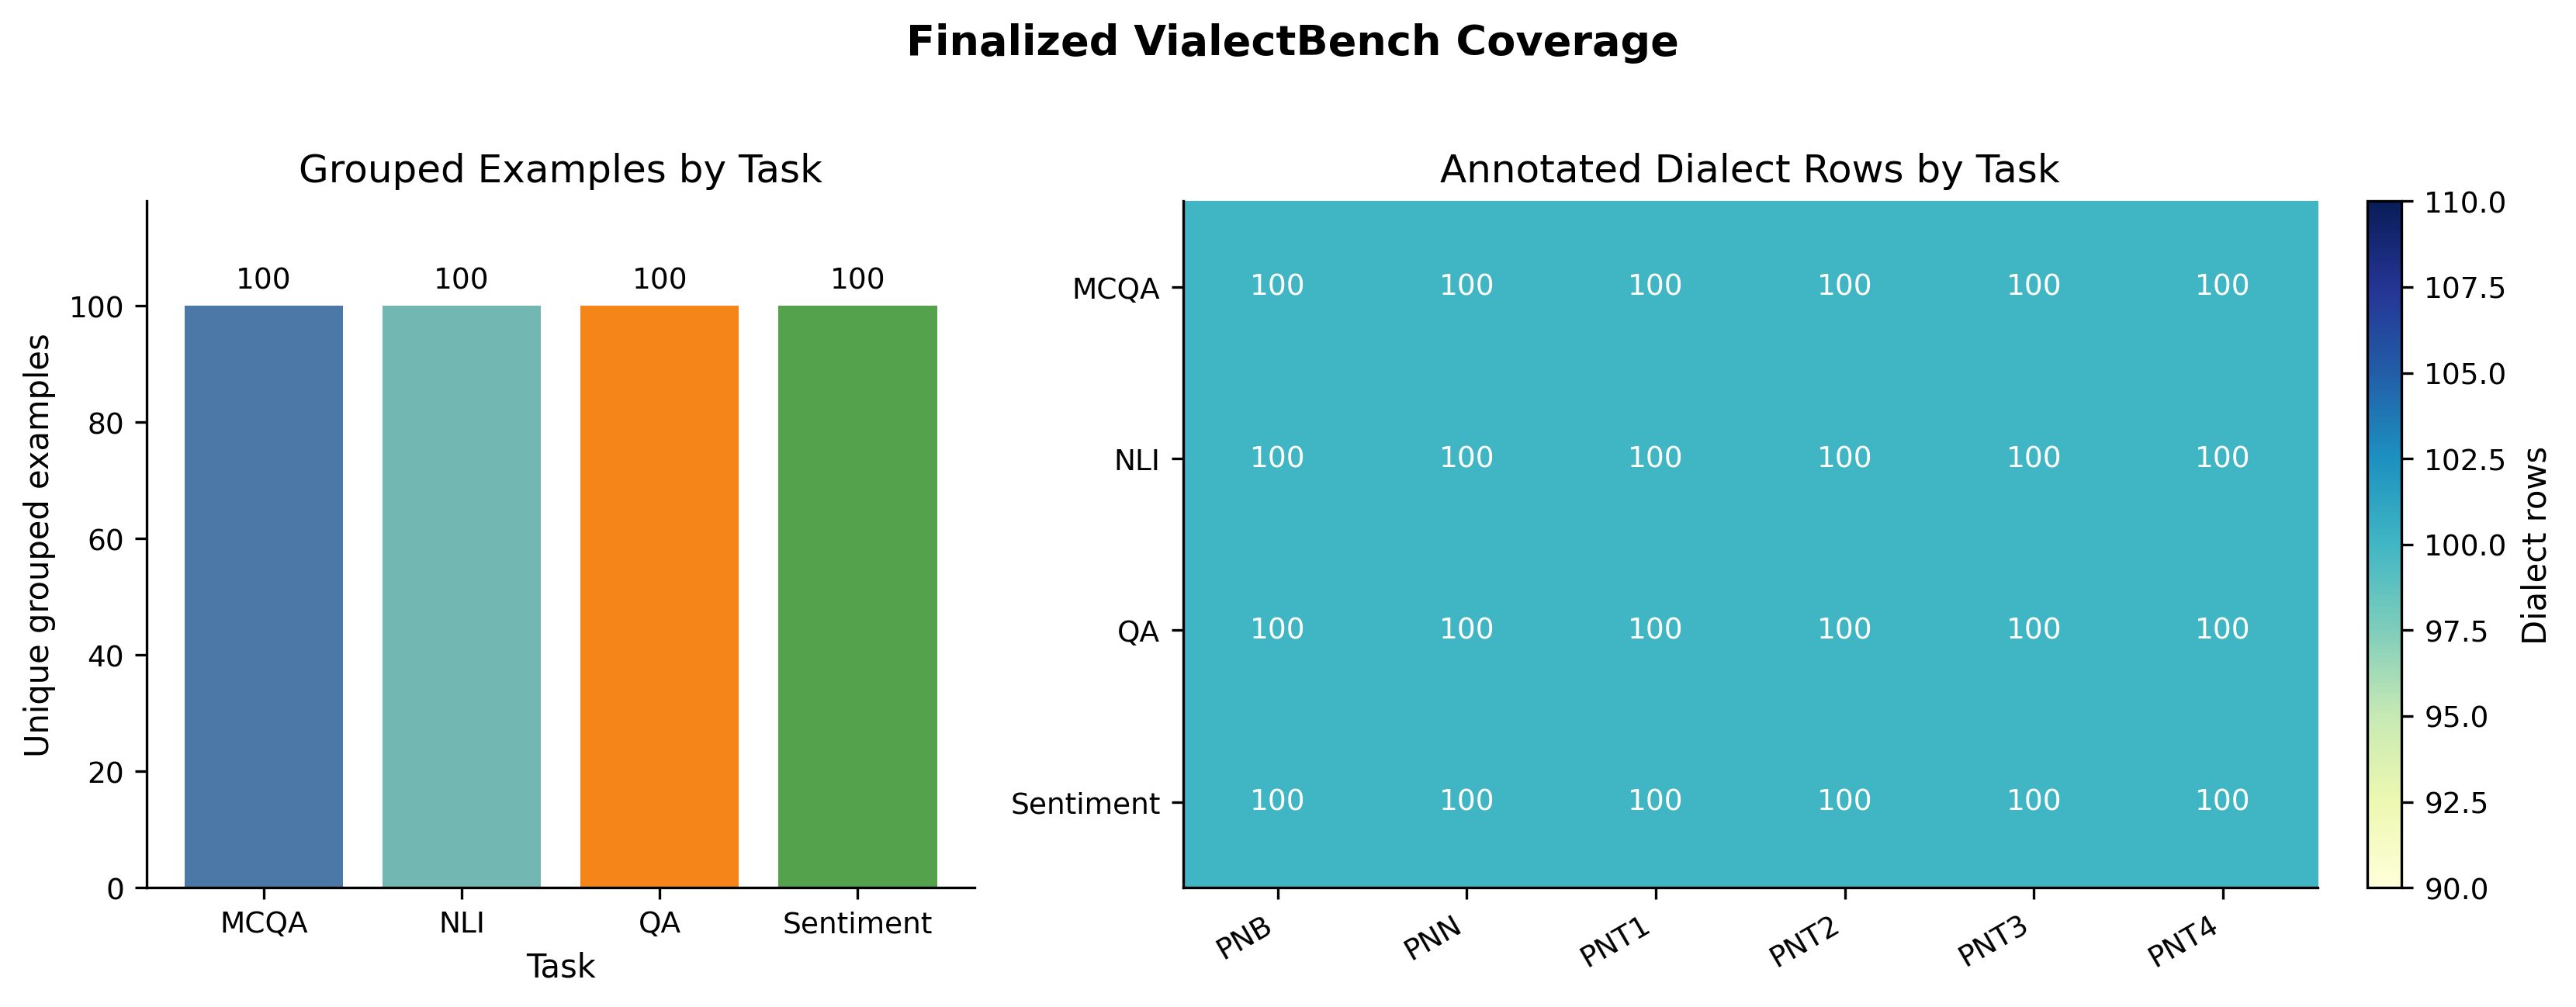

Finalized annotation rows: 2,400
Runnable grouped probe cases: 400


In [1]:
from pathlib import Path
from collections import Counter
import json
import math
import re

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image as DisplayImage, display

ROOT = Path('..') if Path('../data').exists() else Path('.')
FINALIZED_JSON = ROOT / 'data' / 'vialectbench_finalized_6.json'
FINALIZED_PROBE = ROOT / 'data' / 'Finalized' / 'probe_dialects.jsonl'
DATASET_ARTIFACT_DIR = ROOT / 'paper_artifacts' / 'dataset_analysis'
DIRECT_OUTPUT_DIR = ROOT / 'outputs' / 'direct_prompting'
DIRECT_ARTIFACT_DIR = ROOT / 'paper_artifacts' / 'direct_prompting'
DATASET_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
DIRECT_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

DIALECT_ORDER = ['PNB', 'PNN', 'PNT1', 'PNT2', 'PNT3', 'PNT4']
EXPECTED_DIALECTS = DIALECT_ORDER
EXPECTED_VARIANTS = ['standard'] + EXPECTED_DIALECTS
TASK_ORDER = ['MCQA', 'NLI', 'QA', 'SENT']
TASK_LABELS = {'MCQA': 'MCQA', 'NLI': 'NLI', 'QA': 'QA', 'SENT': 'Sentiment'}
DIRECT_TASK_MAP = {'mcqa': 'MCQA', 'nli': 'NLI', 'qa': 'QA', 'sentiment': 'SENT', 'sent': 'SENT'}
EXPECTED_MODELS = [
    ('qwen_2_5_0_5b_instruct', 'Qwen2.5 0.5B'),
    ('qwen_2_5_3b_instruct', 'Qwen2.5 3B'),
    ('qwen_2_5_7b_instruct', 'Qwen2.5 7B'),
    ('llama_3_1_8b_instruct', 'Llama 3.1 8B'),
    ('mistral_7b_instruct_v0_3', 'Mistral 7B'),
    ('gemma_2_9b_it', 'Gemma 2 9B'),
    ('gemma_3_4b_it', 'Gemma 3 4B'),
    ('vistral_7b_chat', 'Vistral 7B'),
    ('seallm_7b_chat', 'SeaLLM 7B'),
    ('gpt_4o', 'GPT-4o'),
]
MODEL_ORDER = [slug for slug, _ in EXPECTED_MODELS]
MODEL_LABELS = dict(EXPECTED_MODELS)
REGION_MAP = {'PNB': 'Northern', 'PNN': 'Southern', 'PNT1': 'Central', 'PNT2': 'Central', 'PNT3': 'Central', 'PNT4': 'Central'}

plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

def save_and_show(fig, artifact_dir: Path, stem: str) -> None:
    png_path = artifact_dir / f'{stem}.png'
    pdf_path = artifact_dir / f'{stem}.pdf'
    fig.savefig(png_path, bbox_inches='tight')
    fig.savefig(pdf_path, bbox_inches='tight')
    print(f'wrote {png_path}')
    print(f'wrote {pdf_path}')
    display(DisplayImage(filename=str(png_path)))
    plt.close(fig)

def save_direct_figure(fig, stem: str) -> None:
    save_and_show(fig, DIRECT_ARTIFACT_DIR, stem)

def save_table(table: pd.DataFrame, artifact_dir: Path, stem: str) -> None:
    csv_path = artifact_dir / f'{stem}.csv'
    tex_path = artifact_dir / f'{stem}.tex'
    table.to_csv(csv_path, index=False)
    table.to_latex(tex_path, index=False, escape=True)
    print(f'wrote {csv_path}')
    print(f'wrote {tex_path}')

def save_direct_table(table: pd.DataFrame, stem: str) -> None:
    save_table(table, DIRECT_ARTIFACT_DIR, stem)

def normalize_answer(value) -> str:
    if isinstance(value, list):
        value = value[0] if value else ''
    if value is None:
        return ''
    text = str(value).lower().strip()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[\.,;:!?\(\)\[\]\{\}"\'`]+', '', text)
    return text.strip()

def exact_match(prediction, gold) -> float:
    golds = gold if isinstance(gold, list) else [gold]
    pred_norm = normalize_answer(prediction)
    return float(any(pred_norm == normalize_answer(g) for g in golds))

def token_f1(prediction, gold) -> float:
    if isinstance(gold, list):
        return max([token_f1(prediction, g) for g in gold] or [0.0])
    pred_tokens = normalize_answer(prediction).split()
    gold_tokens = normalize_answer(gold).split()
    if not pred_tokens and not gold_tokens:
        return 1.0
    if not pred_tokens or not gold_tokens:
        return 0.0
    overlap = sum((Counter(pred_tokens) & Counter(gold_tokens)).values())
    if overlap == 0:
        return 0.0
    precision = overlap / len(pred_tokens)
    recall = overlap / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)

def as_prob_dict(value):
    return value if isinstance(value, dict) and len(value) > 0 else None

def normalized_entropy(prob_dict) -> float:
    probs = as_prob_dict(prob_dict)
    if not probs or len(probs) <= 1:
        return np.nan
    arr = np.array([float(v) for v in probs.values() if pd.notna(v) and float(v) >= 0], dtype=float)
    if arr.sum() <= 0:
        return np.nan
    arr = arr / arr.sum()
    arr = arr[arr > 0]
    return float(-(arr * np.log2(arr)).sum() / math.log2(len(probs)))

def js_divergence(p, q) -> float:
    p = as_prob_dict(p)
    q = as_prob_dict(q)
    if not p or not q:
        return np.nan
    labels = sorted(set(p) | set(q))
    p_arr = np.array([float(p.get(label, 0.0)) for label in labels], dtype=float)
    q_arr = np.array([float(q.get(label, 0.0)) for label in labels], dtype=float)
    if p_arr.sum() <= 0 or q_arr.sum() <= 0:
        return np.nan
    p_arr = p_arr / p_arr.sum()
    q_arr = q_arr / q_arr.sum()
    m_arr = 0.5 * (p_arr + q_arr)
    def kl(a, b):
        mask = a > 0
        return float((a[mask] * np.log2(a[mask] / b[mask])).sum())
    return 0.5 * kl(p_arr, m_arr) + 0.5 * kl(q_arr, m_arr)

def pct_or_dash(value, digits: int = 1) -> str:
    return '-' if pd.isna(value) else f'{100 * value:.{digits}f}'

def num_or_dash(value, digits: int = 1) -> str:
    return '-' if pd.isna(value) else f'{value:.{digits}f}'

# Dataset composition table and coverage figure.
with FINALIZED_JSON.open(encoding='utf-8') as f:
    dataset_rows = json.load(f)
dataset_df = pd.DataFrame(dataset_rows)
dataset_df['task'] = pd.Categorical(dataset_df['task'], categories=TASK_ORDER, ordered=True)
dataset_df['target_dialect'] = pd.Categorical(dataset_df['target_dialect'], categories=DIALECT_ORDER, ordered=True)
dataset_df['sample_group'] = dataset_df['sample_id'].astype(str)

probe_rows = []
if FINALIZED_PROBE.exists():
    probe_rows = [json.loads(line) for line in FINALIZED_PROBE.read_text(encoding='utf-8').splitlines() if line.strip()]
probe_df = pd.DataFrame(probe_rows)

grouped = (
    dataset_df.groupby(['task', 'sample_group'], observed=True)['target_dialect']
    .nunique()
    .reset_index(name='n_dialects')
)
coverage_by_task = (
    grouped.groupby('task', observed=True)
    .agg(
        grouped_examples=('sample_group', 'nunique'),
        mean_dialects_per_example=('n_dialects', 'mean'),
        complete_six_dialect_examples=('n_dialects', lambda s: int((s == 6).sum())),
    )
    .reset_index()
)
composition = (
    dataset_df.groupby('task', observed=True)
    .agg(
        rows=('sample_id', 'size'),
        unique_sample_ids=('sample_id', 'nunique'),
        domains=('domain', lambda s: s.nunique(dropna=True)),
    )
    .reset_index()
    .merge(coverage_by_task, on='task', how='left')
)
composition['task'] = composition['task'].astype(str).map(TASK_LABELS).fillna(composition['task'].astype(str))
composition = composition.rename(columns={
    'task': 'Task',
    'rows': 'Dialect rows',
    'unique_sample_ids': 'Unique sample ids',
    'domains': 'Domains',
    'grouped_examples': 'Grouped examples',
    'mean_dialects_per_example': 'Mean dialects/example',
    'complete_six_dialect_examples': 'Complete six-dialect examples',
})
composition['Mean dialects/example'] = composition['Mean dialects/example'].map(lambda x: f'{x:.2f}')
save_table(composition, DATASET_ARTIFACT_DIR, 'table_dataset_composition')
display(composition)

case_counts = (
    dataset_df.groupby('task', observed=True)['sample_group']
    .nunique()
    .reindex(TASK_ORDER)
    .dropna()
)
heatmap = (
    dataset_df.pivot_table(index='task', columns='target_dialect', values='sample_id', aggfunc='count', fill_value=0, observed=True)
    .reindex(index=TASK_ORDER, columns=DIALECT_ORDER)
    .fillna(0)
    .astype(int)
)
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.2), gridspec_kw={'width_ratios': [0.9, 1.35]})
bar_colors = ['#4C78A8', '#72B7B2', '#F58518', '#54A24B']
axes[0].bar([TASK_LABELS.get(str(x), str(x)) for x in case_counts.index], case_counts.values, color=bar_colors[:len(case_counts)])
axes[0].set_title('Grouped Examples by Task')
axes[0].set_ylabel('Unique grouped examples')
axes[0].set_xlabel('Task')
if len(case_counts) > 0:
    for i, val in enumerate(case_counts.values):
        axes[0].text(i, val + max(case_counts.values) * 0.02, f'{int(val)}', ha='center', va='bottom', fontsize=9)
    axes[0].set_ylim(0, max(case_counts.values) * 1.18)
im = axes[1].imshow(heatmap.values, cmap='YlGnBu', aspect='auto')
axes[1].set_title('Annotated Dialect Rows by Task')
axes[1].set_xticks(range(len(DIALECT_ORDER)), DIALECT_ORDER, rotation=30, ha='right')
axes[1].set_yticks(range(len(heatmap.index)), [TASK_LABELS.get(str(t), str(t)) for t in heatmap.index])
for y in range(heatmap.shape[0]):
    for x_idx in range(heatmap.shape[1]):
        value = int(heatmap.iloc[y, x_idx])
        axes[1].text(x_idx, y, value, ha='center', va='center', color='black' if value < heatmap.values.max() * 0.65 else 'white', fontsize=9)
cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
cbar.set_label('Dialect rows')
fig.suptitle('Finalized VialectBench Coverage', y=1.02, fontsize=13, fontweight='bold')
fig.tight_layout()
save_and_show(fig, DATASET_ARTIFACT_DIR, 'figure_dataset_coverage')
print(f'Finalized annotation rows: {len(dataset_df):,}')
print(f'Runnable grouped probe cases: {len(probe_df):,}')


## Direct Prompting Results: Setup

This cell loads direct-prompting JSONL outputs and constructs the paired Standard-vs-dialect metrics used by all paper tables and figures.

In [2]:
records = []
for path in sorted(DIRECT_OUTPUT_DIR.glob('*.jsonl')):
    model_slug = path.stem
    with path.open(encoding='utf-8') as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            if not str(row.get('raw_output') or '').strip() and not str(row.get('prediction') or '').strip():
                continue
            task = DIRECT_TASK_MAP.get(str(row.get('task', '')).lower(), str(row.get('task', '')).upper())
            variant = row.get('dialect_group') or row.get('variant') or 'standard'
            variant = 'standard' if str(variant).lower() == 'standard' else str(variant)
            prediction = row.get('prediction')
            gold = row.get('gold')
            if task == 'QA':
                em = exact_match(prediction, gold)
                f1 = token_f1(prediction, gold)
                score = f1
                correct = em
                metric_name = 'Token F1'
            else:
                em = exact_match(prediction, gold)
                f1 = np.nan
                score = em
                correct = em
                metric_name = 'Accuracy'
            records.append({
                'model_slug': model_slug,
                'model': row.get('model_name') or MODEL_LABELS.get(model_slug, model_slug),
                'model_short': MODEL_LABELS.get(model_slug, row.get('model_name') or model_slug),
                'model_id': row.get('model_id'),
                'task': task,
                'metric': metric_name,
                'id': str(row.get('id')),
                'variant': variant,
                'is_standard': variant == 'standard',
                'region': REGION_MAP.get(variant),
                'gold': gold,
                'prediction': prediction,
                'prediction_norm': normalize_answer(prediction),
                'score': score,
                'correct': correct,
                'exact_match': em,
                'token_f1': f1,
                'confidence': row.get('confidence', np.nan),
                'gold_prob': row.get('gold_prob', np.nan),
                'label_probs': row.get('label_probs'),
                'entropy': normalized_entropy(row.get('label_probs')),
            })

result_df = pd.DataFrame(records)
if result_df.empty:
    print(f'No direct-prompting files found in {DIRECT_OUTPUT_DIR}')
else:
    result_df['task'] = pd.Categorical(result_df['task'], categories=TASK_ORDER, ordered=True)
    result_df['variant'] = pd.Categorical(result_df['variant'], categories=EXPECTED_VARIANTS, ordered=True)
    result_df['model_slug'] = pd.Categorical(result_df['model_slug'], categories=MODEL_ORDER, ordered=True)
    result_df = result_df.sort_values(['model_slug', 'task', 'id', 'variant']).reset_index(drop=True)

coverage = (
    result_df.groupby(['model_slug', 'task', 'variant'], observed=False)
    .size()
    .reset_index(name='n')
    if not result_df.empty else
    pd.DataFrame(columns=['model_slug', 'task', 'variant', 'n'])
)
coverage_pivot = (
    coverage.pivot_table(index=['model_slug', 'task'], columns='variant', values='n', fill_value=0, observed=False)
    .reindex(pd.MultiIndex.from_product([MODEL_ORDER, TASK_ORDER], names=['model_slug', 'task']), fill_value=0)
    .reset_index()
)
coverage_pivot['model_short'] = coverage_pivot['model_slug'].map(MODEL_LABELS)
coverage_pivot = coverage_pivot[['model_slug', 'model_short', 'task'] + EXPECTED_VARIANTS]
coverage_pivot.to_csv(DIRECT_ARTIFACT_DIR / 'table_direct_prompting_coverage.csv', index=False)

if result_df.empty:
    pair_df = pd.DataFrame()
    summary = pd.DataFrame()
else:
    std_df = (
        result_df[result_df['is_standard']]
        [['model_slug', 'task', 'id', 'score', 'correct', 'prediction_norm', 'confidence', 'gold_prob', 'label_probs', 'entropy']]
        .rename(columns={
            'score': 'standard_score',
            'correct': 'standard_correct',
            'prediction_norm': 'standard_prediction_norm',
            'confidence': 'standard_confidence',
            'gold_prob': 'standard_gold_prob',
            'label_probs': 'standard_label_probs',
            'entropy': 'standard_entropy',
        })
    )
    pair_df = result_df[~result_df['is_standard']].merge(std_df, on=['model_slug', 'task', 'id'], how='left')
    pair_df['performance_drop'] = pair_df['standard_score'] - pair_df['score']
    pair_df['harmful_flip'] = ((pair_df['standard_correct'] == 1.0) & (pair_df['correct'] == 0.0)).astype(float)
    pair_df['beneficial_flip'] = ((pair_df['standard_correct'] == 0.0) & (pair_df['correct'] == 1.0)).astype(float)
    pair_df['prediction_flip'] = (pair_df['standard_prediction_norm'] != pair_df['prediction_norm']).astype(float)
    pair_df['gold_prob_drop'] = pair_df['standard_gold_prob'] - pair_df['gold_prob']
    pair_df['confidence_drop'] = pair_df['standard_confidence'] - pair_df['confidence']
    pair_df['confidence_change'] = pair_df['confidence'] - pair_df['standard_confidence']
    pair_df['entropy_change'] = pair_df['entropy'] - pair_df['standard_entropy']
    pair_df['js_divergence'] = pair_df.apply(lambda r: js_divergence(r.get('standard_label_probs'), r.get('label_probs')), axis=1)

    full_index = pd.MultiIndex.from_product([MODEL_ORDER, TASK_ORDER], names=['model_slug', 'task'])
    standard_perf = (
        result_df[result_df['is_standard']]
        .groupby(['model_slug', 'task'], observed=False)
        .agg(standard_overall_performance=('score', 'mean'), standard_n=('id', 'nunique'))
    )
    paired_standard_perf = (
        pair_df.groupby(['model_slug', 'task'], observed=False)
        .agg(standard_paired_performance=('standard_score', 'mean'))
    )
    dialect_perf = (
        pair_df.groupby(['model_slug', 'task'], observed=False)
        .agg(
            dialect_performance=('score', 'mean'),
            mean_drop=('performance_drop', 'mean'),
            harmful_flip_rate=('harmful_flip', 'mean'),
            beneficial_flip_rate=('beneficial_flip', 'mean'),
            prediction_flip_rate=('prediction_flip', 'mean'),
            dialect_n=('id', 'size'),
        )
    )
    disagreement = (
        pair_df.groupby(['model_slug', 'task', 'id'], observed=False)['prediction_norm']
        .nunique()
        .gt(1)
        .groupby(['model_slug', 'task'], observed=False)
        .mean()
        .to_frame('inter_variant_disagreement')
    )
    summary = standard_perf.join(paired_standard_perf, how='outer').join(dialect_perf, how='outer').join(disagreement, how='outer').reindex(full_index).reset_index()
    summary['standard_performance'] = summary['standard_paired_performance'].combine_first(summary['standard_overall_performance'])
    summary['model_short'] = summary['model_slug'].map(MODEL_LABELS)
    summary['task_label'] = summary['task'].map(TASK_LABELS)

print(f'Loaded {len(result_df):,} direct-prompting rows from {result_df["model_slug"].nunique() if not result_df.empty else 0} available models')
print(f'Paired dialect rows: {len(pair_df):,}')
display(coverage_pivot.head(20))


Loaded 28,000 direct-prompting rows from 10 available models
Paired dialect rows: 24,000


variant,model_slug,model_short,task,standard,PNB,PNN,PNT1,PNT2,PNT3,PNT4
0,qwen_2_5_0_5b_instruct,Qwen2.5 0.5B,MCQA,100,100,100,100,100,100,100
1,qwen_2_5_0_5b_instruct,Qwen2.5 0.5B,NLI,100,100,100,100,100,100,100
2,qwen_2_5_0_5b_instruct,Qwen2.5 0.5B,QA,100,100,100,100,100,100,100
3,qwen_2_5_0_5b_instruct,Qwen2.5 0.5B,SENT,100,100,100,100,100,100,100
4,qwen_2_5_3b_instruct,Qwen2.5 3B,MCQA,100,100,100,100,100,100,100
5,qwen_2_5_3b_instruct,Qwen2.5 3B,NLI,100,100,100,100,100,100,100
6,qwen_2_5_3b_instruct,Qwen2.5 3B,QA,100,100,100,100,100,100,100
7,qwen_2_5_3b_instruct,Qwen2.5 3B,SENT,100,100,100,100,100,100,100
8,qwen_2_5_7b_instruct,Qwen2.5 7B,MCQA,100,100,100,100,100,100,100
9,qwen_2_5_7b_instruct,Qwen2.5 7B,NLI,100,100,100,100,100,100,100


## Direct Prompting Results: Task Performance Matrix

The table below summarizes model performance by task in a paper-style matrix: each task reports Standard Vietnamese performance, mean dialect performance, and the paired dialect-induced drop.

wrote ..\paper_artifacts\direct_prompting\paper_table_task_performance_matrix.csv
wrote ..\paper_artifacts\direct_prompting\paper_table_task_performance_matrix.tex


,Model,Setting,MCQA Std.,MCQA Dial.,MCQA Delta,NLI Std.,NLI Dial.,NLI Delta,QA Std.,QA Dial.,QA Delta,Sent. Std.,Sent. Dial.,Sent. Delta,All Std.,All Dial.,All Delta
0,Qwen2.5 0.5B,Direct,68.0,60.5,7.5,33.0,33.0,0.0,38.9,29.8,9.2,24.0,22.5,1.5,41.0,36.4,4.5
1,Qwen2.5 3B,Direct,92.0,88.0,4.0,55.0,54.3,0.7,69.2,62.7,6.4,51.0,44.7,6.3,66.8,62.4,4.4
2,Qwen2.5 7B,Direct,91.0,87.8,3.2,64.0,61.2,2.8,74.7,69.8,4.9,38.0,38.2,-0.2,66.9,64.2,2.7
3,Llama 3.1 8B,Direct,87.0,83.2,3.8,48.0,45.5,2.5,79.4,76.5,2.9,43.0,39.8,3.2,64.3,61.2,3.1
4,Mistral 7B,Direct,73.0,70.7,2.3,47.0,47.8,-0.8,54.3,42.0,12.2,37.0,35.7,1.3,52.8,49.1,3.8
5,Gemma 2 9B,Direct,94.0,94.2,-0.2,63.0,61.0,2.0,84.1,81.8,2.3,49.0,43.2,5.8,72.5,70.0,2.5
6,Gemma 3 4B,Direct,89.0,87.8,1.2,55.0,52.2,2.8,79.6,75.6,3.9,43.0,41.7,1.3,66.6,64.3,2.3
7,Vistral 7B,Direct,88.0,87.2,0.8,19.0,18.5,0.5,66.2,61.5,4.7,32.0,32.0,0.0,51.3,49.8,1.5
8,SeaLLM 7B,Direct,91.0,88.3,2.7,46.0,44.8,1.2,74.3,68.2,6.0,37.0,37.0,0.0,62.1,59.6,2.5
9,GPT-4o,Direct,94.0,93.8,0.2,74.0,71.2,2.8,83.2,83.8,-0.5,60.0,58.5,1.5,77.8,76.8,1.0


wrote ..\paper_artifacts\direct_prompting\paper_figure_task_performance_matrix.png
wrote ..\paper_artifacts\direct_prompting\paper_figure_task_performance_matrix.pdf


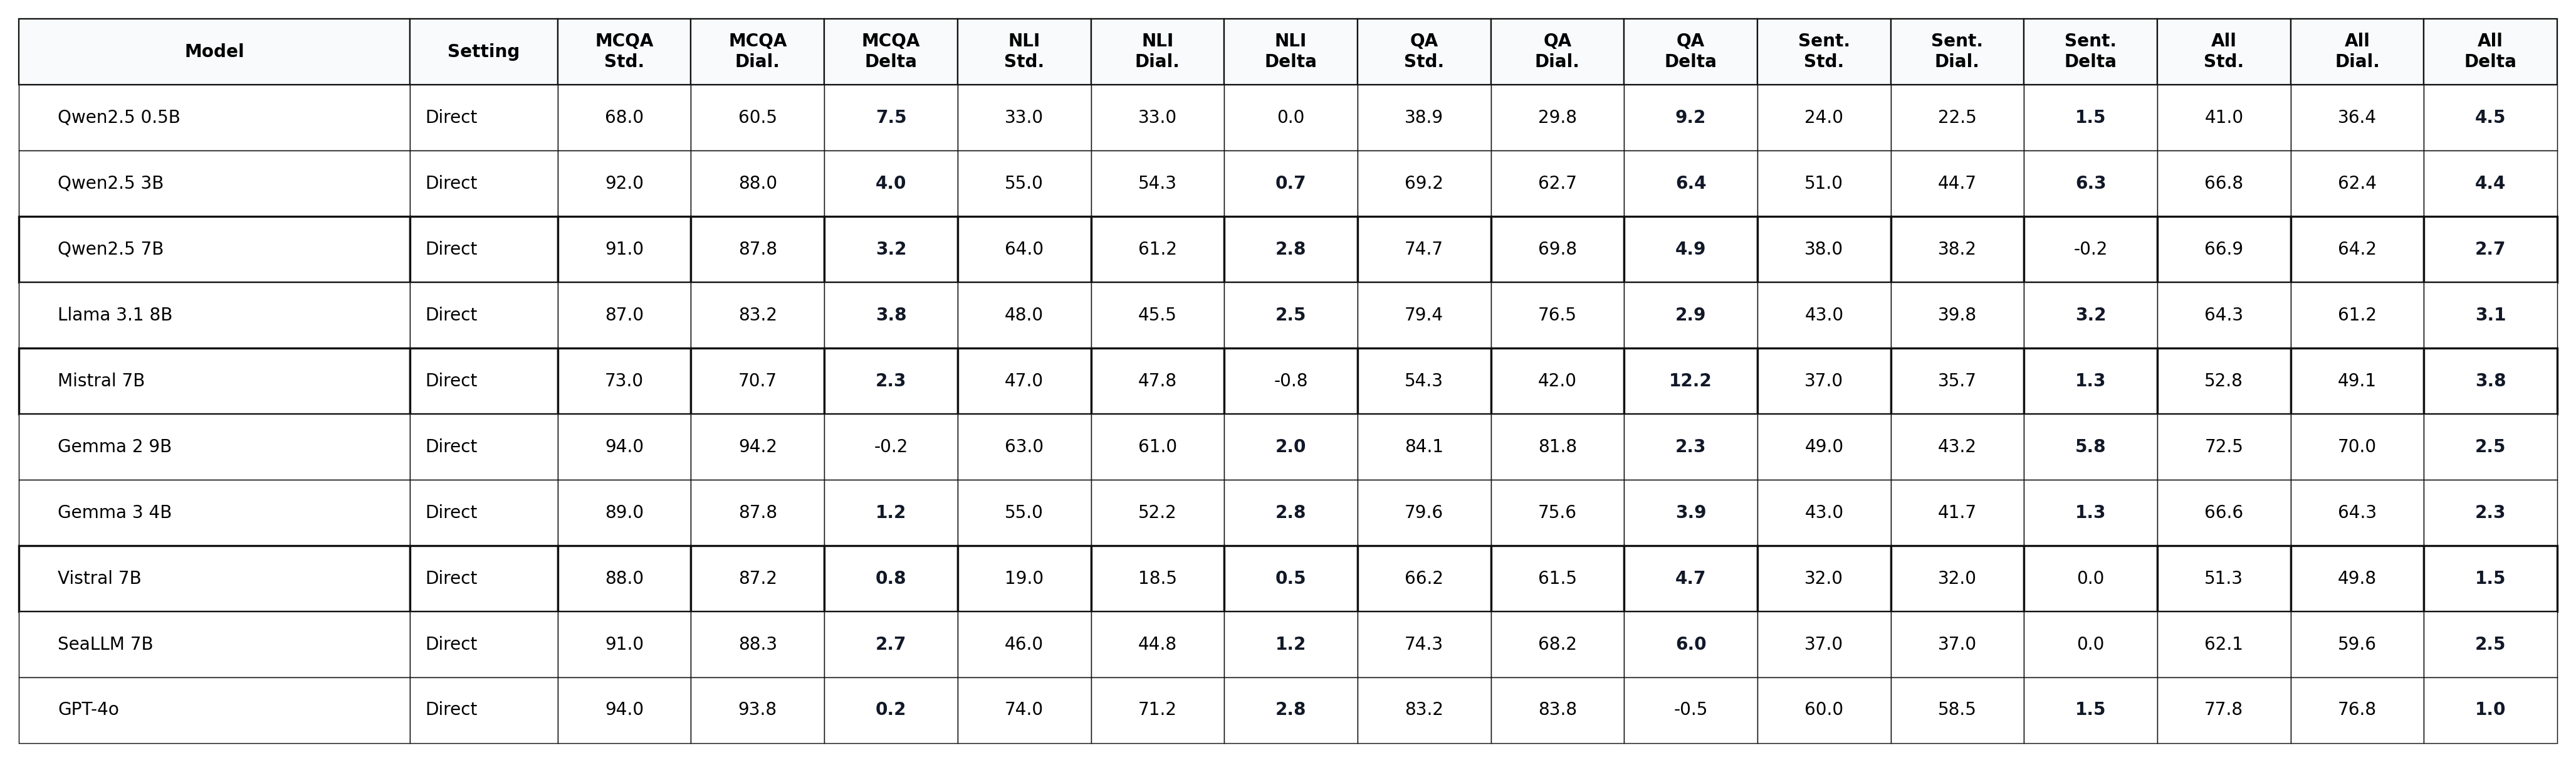

In [3]:
TASK_MATRIX_STEM = 'paper_table_task_performance_matrix'
TASK_MATRIX_FIG_STEM = 'paper_figure_task_performance_matrix'
TASK_MATRIX_TASKS = ['MCQA', 'NLI', 'QA', 'SENT']
TASK_MATRIX_LABELS = {'MCQA': 'MCQA', 'NLI': 'NLI', 'QA': 'QA', 'SENT': 'Sent.'}

def fmt_pct_one(value):
    return '-' if pd.isna(value) else f'{100 * value:.1f}'

def task_metric_value(model_slug, task, column):
    if summary.empty:
        return np.nan
    sub = summary[(summary['model_slug'] == model_slug) & (summary['task'] == task)]
    if sub.empty:
        return np.nan
    return sub.iloc[0].get(column, np.nan)

def make_task_matrix_rows():
    rows = []
    for model_slug in MODEL_ORDER:
        row = {
            'Model': MODEL_LABELS.get(model_slug, model_slug),
            'Setting': 'Direct',
        }
        for task in TASK_MATRIX_TASKS:
            std = task_metric_value(model_slug, task, 'standard_performance')
            dialect = task_metric_value(model_slug, task, 'dialect_performance')
            drop = task_metric_value(model_slug, task, 'mean_drop')
            row[f'{task}_std'] = std
            row[f'{task}_dialect'] = dialect
            row[f'{task}_delta'] = drop

        if pair_df.empty:
            all_std = all_dialect = all_delta = np.nan
        else:
            model_pairs = pair_df[pair_df['model_slug'] == model_slug]
            if model_pairs.empty:
                all_std = all_dialect = all_delta = np.nan
            else:
                all_std = model_pairs['standard_score'].mean()
                all_dialect = model_pairs['score'].mean()
                all_delta = model_pairs['performance_drop'].mean()
        row['ALL_std'] = all_std
        row['ALL_dialect'] = all_dialect
        row['ALL_delta'] = all_delta
        rows.append(row)
    return rows

task_matrix_raw = pd.DataFrame(make_task_matrix_rows())
flat_columns = ['Model', 'Setting']
for task in TASK_MATRIX_TASKS + ['ALL']:
    flat_columns.extend([f'{task}_std', f'{task}_dialect', f'{task}_delta'])
task_matrix_raw = task_matrix_raw[flat_columns]

task_matrix_csv = task_matrix_raw.copy()
task_matrix_csv.columns = [
    'Model', 'Setting',
    'MCQA Standard', 'MCQA Dialect', 'MCQA Delta',
    'NLI Standard', 'NLI Dialect', 'NLI Delta',
    'QA Standard', 'QA Dialect', 'QA Delta',
    'Sentiment Standard', 'Sentiment Dialect', 'Sentiment Delta',
    'All Standard', 'All Dialect', 'All Delta',
]
task_matrix_csv.to_csv(DIRECT_ARTIFACT_DIR / f'{TASK_MATRIX_STEM}.csv', index=False)
print(f'wrote {DIRECT_ARTIFACT_DIR / f"{TASK_MATRIX_STEM}.csv"}')

task_matrix_display = task_matrix_raw.copy()
for col in task_matrix_display.columns:
    if col not in {'Model', 'Setting'}:
        task_matrix_display[col] = task_matrix_display[col].map(fmt_pct_one)
task_matrix_display.columns = [
    'Model', 'Setting',
    'MCQA Std.', 'MCQA Dial.', 'MCQA Delta',
    'NLI Std.', 'NLI Dial.', 'NLI Delta',
    'QA Std.', 'QA Dial.', 'QA Delta',
    'Sent. Std.', 'Sent. Dial.', 'Sent. Delta',
    'All Std.', 'All Dial.', 'All Delta',
]

def latex_escape(text):
    text = str(text)
    replacements = {
        '\\': r'\textbackslash{}',
        '&': r'\&',
        '%': r'\%',
        '$': r'\$',
        '#': r'\#',
        '_': r'\_',
        '{': r'\{',
        '}': r'\}',
        '~': r'\textasciitilde{}',
        '^': r'\textasciicircum{}',
    }
    for src, dst in replacements.items():
        text = text.replace(src, dst)
    return text

def latex_value(value, is_delta=False):
    if value == '-':
        return '-'
    if is_delta:
        try:
            numeric = float(value)
        except ValueError:
            return value
        if numeric > 0:
            return rf'\textbf{{{numeric:.1f}}}'
        return f'{numeric:.1f}'
    return value

latex_lines = []
latex_lines.append(r'\begin{table*}[t]')
latex_lines.append(r'\centering')
latex_lines.append(r'\scriptsize')
latex_lines.append(r'\setlength{\tabcolsep}{2.6pt}')
latex_lines.append(r'\renewcommand{\arraystretch}{1.08}')
latex_lines.append(r'\caption{Task-level direct prompting performance on VialectBench. Standard and Dial. denote performance on Standard Vietnamese and the mean over dialect variants, respectively. $\Delta$ is the paired Standard-minus-Dialect performance drop. QA uses token-level F1; the other tasks use accuracy.}')
latex_lines.append(r'\label{tab:task-performance-matrix}')
latex_lines.append(r'\resizebox{\textwidth}{!}{%')
latex_lines.append(r'\begin{tabular}{ll' + 'ccc' * 5 + r'}')
latex_lines.append(r'\toprule')
latex_lines.append(r'\textbf{Model} & \textbf{Setting} & \multicolumn{3}{c}{\textbf{MCQA}} & \multicolumn{3}{c}{\textbf{NLI}} & \multicolumn{3}{c}{\textbf{QA}} & \multicolumn{3}{c}{\textbf{Sent.}} & \multicolumn{3}{c}{\textbf{All}} \\')
latex_lines.append(r'\cmidrule(lr){3-5}\cmidrule(lr){6-8}\cmidrule(lr){9-11}\cmidrule(lr){12-14}\cmidrule(lr){15-17}')
latex_lines.append(r' & & Std. & Dial. & $\Delta$ & Std. & Dial. & $\Delta$ & Std. & Dial. & $\Delta$ & Std. & Dial. & $\Delta$ & Std. & Dial. & $\Delta$ \\')
latex_lines.append(r'\midrule')
separator_after = {2, 4, 7}
for idx, row in task_matrix_display.iterrows():
    values = [latex_escape(row['Model']), latex_escape(row['Setting'])]
    for task in ['MCQA', 'NLI', 'QA', 'Sent.', 'All']:
        values.append(latex_value(row[f'{task} Std.']))
        values.append(latex_value(row[f'{task} Dial.']))
        values.append(latex_value(row[f'{task} Delta'], is_delta=True))
    latex_lines.append(' & '.join(values) + r' \\')
    if idx in separator_after:
        latex_lines.append(r'\midrule')
latex_lines.append(r'\bottomrule')
latex_lines.append(r'\end{tabular}%')
latex_lines.append(r'}')
latex_lines.append(r'\end{table*}')
latex_path = DIRECT_ARTIFACT_DIR / f'{TASK_MATRIX_STEM}.tex'
latex_path.write_text('\n'.join(latex_lines), encoding='utf-8')
print(f'wrote {latex_path}')

display(task_matrix_display)

fig, ax = plt.subplots(figsize=(13.8, 4.15))
ax.axis('off')
col_labels = [
    'Model', 'Setting',
    'MCQA\nStd.', 'MCQA\nDial.', 'MCQA\nDelta',
    'NLI\nStd.', 'NLI\nDial.', 'NLI\nDelta',
    'QA\nStd.', 'QA\nDial.', 'QA\nDelta',
    'Sent.\nStd.', 'Sent.\nDial.', 'Sent.\nDelta',
    'All\nStd.', 'All\nDial.', 'All\nDelta',
]
cell_text = task_matrix_display.values.tolist()
col_widths = [0.138, 0.052] + [0.047] * 15
table = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    colLoc='center',
    cellLoc='center',
    colWidths=col_widths,
    bbox=[0.0, 0.0, 1.0, 1.0],
)
table.auto_set_font_size(False)
table.set_fontsize(6.7)
table.scale(1.0, 1.24)
for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor('#111111')
    cell.set_linewidth(0.35)
    if r == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#f8fafc')
        cell.set_linewidth(0.55)
    elif c in [0, 1]:
        cell.set_text_props(ha='left')
    if r > 0 and c in [4, 7, 10, 13, 16]:
        text = cell.get_text().get_text()
        try:
            if text != '-' and float(text) > 0:
                cell.set_text_props(weight='bold', color='#111827')
        except ValueError:
            pass
for row_idx in [3, 5, 8]:
    if row_idx <= len(task_matrix_display):
        for c in range(len(col_labels)):
            table[(row_idx, c)].set_linewidth(0.8)
fig.tight_layout()
save_direct_figure(fig, TASK_MATRIX_FIG_STEM)


In [4]:
TASK_DIALECT_MATRIX_STEM = 'paper_table_task_dialect_performance_matrix'
TASK_DIALECT_MATRIX_FIG_STEM = 'paper_figure_task_dialect_performance_matrix'
TASK_DIALECT_VARIANT_LABELS = {'standard': 'Standard', **{dialect: dialect for dialect in EXPECTED_DIALECTS}}
TASK_DIALECT_TASK_LABELS = {**TASK_MATRIX_LABELS, 'SENT': 'Emotion'}

if result_df.empty:
    task_dialect_matrix_raw = pd.DataFrame(columns=['Task', 'Variant'] + MODEL_ORDER)
else:
    ordered_index = pd.MultiIndex.from_product(
        [TASK_MATRIX_TASKS, EXPECTED_VARIANTS],
        names=['task', 'variant'],
    )
    task_rows = (
        result_df.groupby(['task', 'variant', 'model_slug'], observed=False)
        .agg(score=('score', 'mean'))
        .reset_index()
        .pivot_table(
            index=['task', 'variant'],
            columns='model_slug',
            values='score',
            observed=False,
        )
        .reindex(ordered_index)
        .reindex(columns=MODEL_ORDER)
        .reset_index()
    )
    task_rows['Task'] = task_rows['task'].map(TASK_DIALECT_TASK_LABELS)
    task_rows['Variant'] = task_rows['variant'].map(TASK_DIALECT_VARIANT_LABELS)
    task_rows = task_rows[['task', 'variant', 'Task', 'Variant'] + MODEL_ORDER]

    all_rows = (
        task_rows.groupby(['variant', 'Variant'], sort=False, observed=False)[MODEL_ORDER]
        .mean()
        .reindex(
            pd.MultiIndex.from_tuples(
                [(variant, TASK_DIALECT_VARIANT_LABELS[variant]) for variant in EXPECTED_VARIANTS],
                names=['variant', 'Variant'],
            )
        )
        .reset_index()
    )
    all_rows.insert(0, 'Task', 'ALL')
    all_rows.insert(0, 'task', 'ALL')

    task_dialect_matrix_raw = pd.concat(
        [task_rows[['task', 'Task', 'Variant'] + MODEL_ORDER], all_rows[['task', 'Task', 'Variant'] + MODEL_ORDER]],
        ignore_index=True,
    )

raw_export = task_dialect_matrix_raw.drop(columns=['task'], errors='ignore').rename(columns=MODEL_LABELS)
raw_export.to_csv(DIRECT_ARTIFACT_DIR / f'{TASK_DIALECT_MATRIX_STEM}.csv', index=False)
print(f'wrote {DIRECT_ARTIFACT_DIR / f"{TASK_DIALECT_MATRIX_STEM}.csv"}')

task_dialect_matrix_display = task_dialect_matrix_raw.drop(columns=['task'], errors='ignore').copy()
for model_slug in MODEL_ORDER:
    task_dialect_matrix_display[model_slug] = task_dialect_matrix_display[model_slug].map(fmt_pct_one)
task_dialect_matrix_display = task_dialect_matrix_display.rename(columns=MODEL_LABELS)

display_rows = task_dialect_matrix_display.copy()
display_rows.loc[display_rows['Task'].duplicated(), 'Task'] = ''

all_standard = None
if not task_dialect_matrix_raw.empty:
    all_standard_rows = task_dialect_matrix_raw[
        (task_dialect_matrix_raw['Task'] == 'ALL')
        & (task_dialect_matrix_raw['Variant'] == 'Standard')
    ]
    if not all_standard_rows.empty:
        all_standard = all_standard_rows.iloc[0]

def all_change_pp(raw_row: pd.Series, model_slug: str) -> float | None:
    if all_standard is None or raw_row.get('Task') != 'ALL' or raw_row.get('Variant') == 'Standard':
        return None
    value = raw_row.get(model_slug)
    standard = all_standard.get(model_slug)
    if pd.isna(value) or pd.isna(standard):
        return None
    return float((value - standard) * 100)

def arrow_for_change(change: float) -> str:
    if change > 0.05:
        return r'\uparrow'
    if change < -0.05:
        return r'\downarrow'
    return r'\rightarrow'

def latex_model_value(raw_row: pd.Series, display_row: pd.Series, model_slug: str) -> str:
    value = display_row[MODEL_LABELS[model_slug]]
    if value == '-':
        return value
    main = rf'{{\footnotesize {latex_escape(value)}}}'
    change = all_change_pp(raw_row, model_slug)
    if change is None:
        return main
    arrow = arrow_for_change(change)
    return main + rf'{{\tiny\,${arrow}${change:+.1f}}}'

def figure_model_value(raw_row: pd.Series, display_row: pd.Series, model_slug: str) -> str:
    value = display_row[MODEL_LABELS[model_slug]]
    change = all_change_pp(raw_row, model_slug)
    if change is None:
        return value
    arrow = arrow_for_change(change)
    return f'{value}\n${arrow}${change:+.1f}'

latex_lines = []
latex_lines.append(r'\begin{table*}[t]')
latex_lines.append(r'\centering')
latex_lines.append(r'\scriptsize')
latex_lines.append(r'\setlength{\tabcolsep}{2.7pt}')
latex_lines.append(r'\renewcommand{\arraystretch}{1.05}')
latex_lines.append(r'\resizebox{\textwidth}{!}{%')
latex_lines.append(r'\begin{tabular}{ll' + 'r' * len(MODEL_ORDER) + r'}')
latex_lines.append(r'\toprule')
latex_lines.append(' & '.join(['Task', 'Variant'] + [latex_escape(MODEL_LABELS[m]) for m in MODEL_ORDER]) + r' \\')
latex_lines.append(r'\midrule')
for row_idx, row in display_rows.iterrows():
    raw_row = task_dialect_matrix_raw.iloc[row_idx]
    values = [latex_escape(row['Task']), latex_escape(row['Variant'])]
    values.extend(latex_model_value(raw_row, row, model_slug) for model_slug in MODEL_ORDER)
    latex_lines.append(' & '.join(values) + r' \\')
    if row_idx % len(EXPECTED_VARIANTS) == len(EXPECTED_VARIANTS) - 1 and row_idx != len(display_rows) - 1:
        latex_lines.append(r'\midrule')
latex_lines.append(r'\bottomrule')
latex_lines.append(r'\end{tabular}%')
latex_lines.append(r'}')
latex_lines.append(r'\caption{Task-by-dialect performance (\%). Rows list Standard Vietnamese and each dialect variant separately; ALL averages the four task scores for each model and variant, with tiny arrows showing dialect-minus-Standard change.}')
latex_lines.append(r'\label{tab:task-dialect-performance-matrix}')
latex_lines.append(r'\end{table*}')
latex_path = DIRECT_ARTIFACT_DIR / f'{TASK_DIALECT_MATRIX_STEM}.tex'
latex_path.write_text('\n'.join(latex_lines), encoding='utf-8')
print(f'wrote {latex_path}')

display(task_dialect_matrix_display)

figure_rows = display_rows.copy()
for row_idx, row in figure_rows.iterrows():
    raw_row = task_dialect_matrix_raw.iloc[row_idx]
    for model_slug in MODEL_ORDER:
        figure_rows.at[row_idx, MODEL_LABELS[model_slug]] = figure_model_value(raw_row, row, model_slug)

fig, ax = plt.subplots(figsize=(12.8, 10.2))
ax.axis('off')
col_labels = ['Task', 'Variant'] + [MODEL_LABELS[m].replace(' ', '\n', 1) for m in MODEL_ORDER]
col_widths = [0.075, 0.066] + [0.0859] * len(MODEL_ORDER)
table = ax.table(
    cellText=figure_rows.values.tolist(),
    colLabels=col_labels,
    colLoc='center',
    cellLoc='center',
    colWidths=col_widths,
    bbox=[0.0, 0.0, 1.0, 1.0],
)
table.auto_set_font_size(False)
table.set_fontsize(5.55)
table.scale(1.0, 1.09)
for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor('#111111')
    cell.set_linewidth(0.28)
    if r == 0:
        cell.set_text_props(weight='bold', fontsize=5.55)
        cell.set_facecolor('#f8fafc')
        cell.set_linewidth(0.55)
    elif c in [0, 1]:
        cell.set_text_props(ha='left', fontsize=5.55)
    elif r > 0:
        is_all_dialect = (
            task_dialect_matrix_raw.iloc[r - 1]['Task'] == 'ALL'
            and task_dialect_matrix_raw.iloc[r - 1]['Variant'] != 'Standard'
        )
        cell.set_text_props(fontsize=5.2 if is_all_dialect else 6.25)
    if r > 0 and display_rows.iloc[r - 1]['Variant'] == 'Standard':
        cell.set_facecolor('#eef2ff')
        cell.set_linewidth(0.45)
    if r > 0 and c >= 2:
        text = display_rows.iloc[r - 1, c]
        try:
            if text != '-' and float(text) >= 80.0:
                cell.set_text_props(weight='bold', color='#111827')
        except ValueError:
            pass
for boundary in range(len(EXPECTED_VARIANTS), len(display_rows), len(EXPECTED_VARIANTS)):
    for c in range(len(col_labels)):
        table[(boundary, c)].set_linewidth(0.75)
ax.set_title('Task and Dialect Performance Matrix', fontsize=10, pad=8)
fig.tight_layout()
save_direct_figure(fig, TASK_DIALECT_MATRIX_FIG_STEM)

wrote ..\paper_artifacts\direct_prompting\paper_table_task_dialect_performance_matrix.csv


TypeError: unsupported operand type(s) for |: 'type' and 'NoneType'

## Analysis 1: Overall Robustness Overview

The table gives the broad Standard-vs-dialect picture by model and task. The figure presents the same paired Standard and dialect performance comparison.

In [ ]:
main_table = summary[['model_short', 'task_label', 'standard_performance', 'dialect_performance', 'mean_drop', 'harmful_flip_rate', 'beneficial_flip_rate', 'prediction_flip_rate', 'inter_variant_disagreement', 'standard_n', 'dialect_n']].copy()
main_table = main_table.rename(columns={
    'model_short': 'Model',
    'task_label': 'Task',
    'standard_performance': 'Std.',
    'dialect_performance': 'Dialect',
    'mean_drop': 'Drop',
    'harmful_flip_rate': 'Harmful flip',
    'beneficial_flip_rate': 'Beneficial flip',
    'prediction_flip_rate': 'Prediction flip',
    'inter_variant_disagreement': 'Dialect disagree',
    'standard_n': 'Std. n',
    'dialect_n': 'Dialect n',
})
formatted_main_table = main_table.copy()
for col in ['Std.', 'Dialect', 'Drop', 'Harmful flip', 'Beneficial flip', 'Prediction flip', 'Dialect disagree']:
    formatted_main_table[col] = formatted_main_table[col].map(pct_or_dash)
for col in ['Std. n', 'Dialect n']:
    formatted_main_table[col] = formatted_main_table[col].map(lambda x: '-' if pd.isna(x) or int(x) == 0 else str(int(x)))
save_direct_table(formatted_main_table, 'table_direct_prompting_main')
display(formatted_main_table)


wrote ..\paper_artifacts\direct_prompting\table_direct_prompting_main.csv
wrote ..\paper_artifacts\direct_prompting\table_direct_prompting_main.tex


,Model,Task,Std.,Dialect,Drop,Harmful flip,Beneficial flip,Prediction flip,Dialect disagree,Std. n,Dialect n
0,Qwen2.5 0.5B,MCQA,68.0,60.5,7.5,11.7,4.2,19.7,11.8,100,600
1,Qwen2.5 0.5B,NLI,33.0,33.0,0.0,0.0,0.0,0.0,0.0,100,600
2,Qwen2.5 0.5B,QA,38.9,29.8,9.2,3.8,0.8,55.5,23.5,100,600
3,Qwen2.5 0.5B,Sentiment,24.0,22.5,1.5,4.2,2.7,19.7,12.0,100,600
4,Qwen2.5 3B,MCQA,92.0,88.0,4.0,4.2,0.2,4.7,2.8,100,600
5,Qwen2.5 3B,NLI,55.0,54.3,0.7,5.2,4.5,11.0,10.0,100,600
6,Qwen2.5 3B,QA,69.2,62.7,6.4,4.3,1.3,27.0,14.2,100,600
7,Qwen2.5 3B,Sentiment,51.0,44.7,6.3,10.8,4.5,23.5,15.8,100,600
8,Qwen2.5 7B,MCQA,91.0,87.8,3.2,3.8,0.7,5.0,3.5,100,600
9,Qwen2.5 7B,NLI,64.0,61.2,2.8,5.5,2.7,10.0,8.5,100,600


wrote ..\paper_artifacts\direct_prompting\figure_direct_prompting_standard_vs_dialect.png
wrote ..\paper_artifacts\direct_prompting\figure_direct_prompting_standard_vs_dialect.pdf


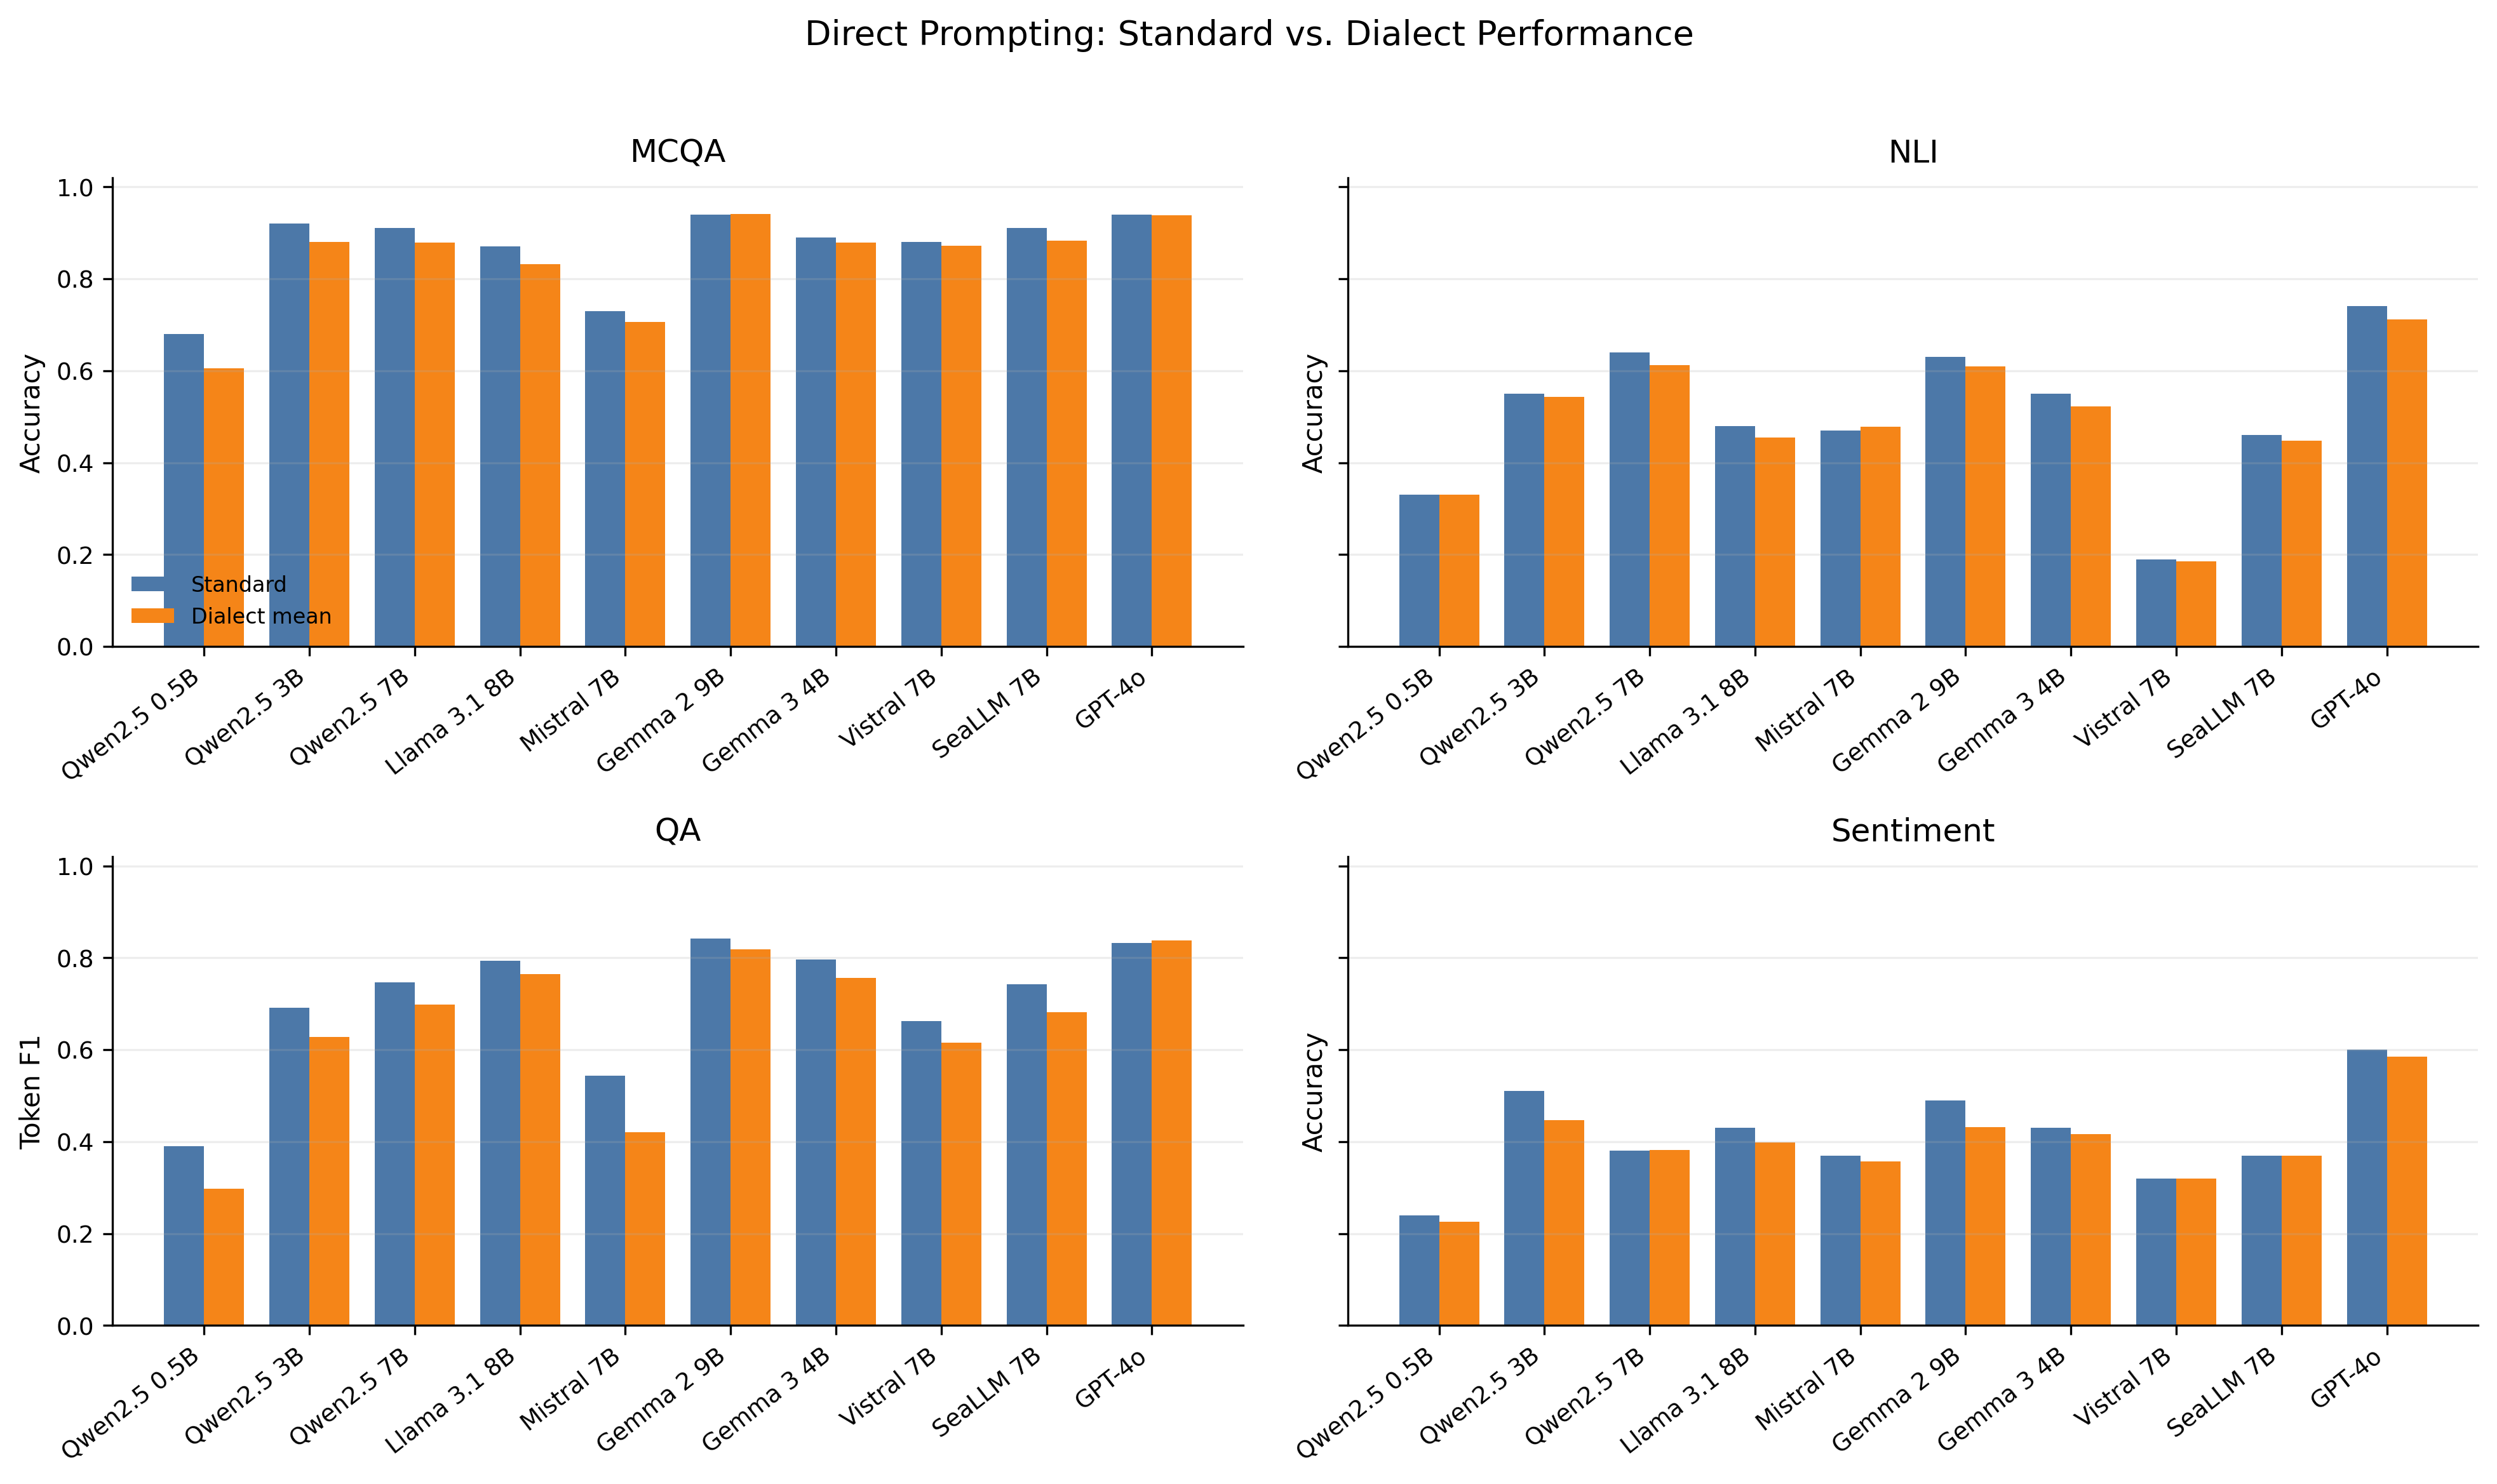

In [ ]:
plot_summary = summary.copy()
plot_summary['standard_performance_plot'] = plot_summary['standard_performance'].fillna(0.0)
plot_summary['dialect_performance_plot'] = plot_summary['dialect_performance'].fillna(0.0)

fig, axes = plt.subplots(2, 2, figsize=(13.2, 7.6), sharey=True)
axes = axes.ravel()
x = np.arange(len(MODEL_ORDER))
width = 0.38
for ax, task in zip(axes, TASK_ORDER):
    sub = plot_summary[plot_summary['task'] == task].set_index('model_slug').reindex(MODEL_ORDER)
    ax.bar(x - width / 2, sub['standard_performance_plot'], width=width, label='Standard', color='#4C78A8')
    ax.bar(x + width / 2, sub['dialect_performance_plot'], width=width, label='Dialect mean', color='#F58518')
    ax.set_title(TASK_LABELS[task])
    ax.set_ylim(0, 1.02)
    ax.set_ylabel('Accuracy' if task != 'QA' else 'Token F1')
    ax.set_xticks(x, [MODEL_LABELS[m] for m in MODEL_ORDER], rotation=38, ha='right')
    ax.grid(axis='y', alpha=0.22)
axes[0].legend(loc='lower left', frameon=False)
fig.suptitle('Direct Prompting: Standard vs. Dialect Performance', y=1.02, fontsize=13)
fig.tight_layout()
save_direct_figure(fig, 'figure_direct_prompting_standard_vs_dialect')


## Analysis 2: Region-Level Model Performance

The table reports model performance on Standard Vietnamese and each dialect group. The figure aggregates dialect groups into Northern, Central, and Southern regions, with a right-axis marker for harmful flip rate.

**Note.** `paper_table_all_model_dialect_performance` reports absolute scores. Its `Standard` column is averaged over all paired dialect rows for a model; dialect columns are absolute dialect scores. Do not subtract that overall `Standard` column from a dialect column to obtain dialect-specific robustness.


In [ ]:
# NOTE: This table reports absolute scores. The 'Standard' column is the mean standard score over all paired dialect rows for each model, while each dialect column is that dialect's mean score. Do not subtract the table's overall Standard column from a dialect column to get a dialect-specific drop; use the paired-difference heatmap for that.

if pair_df.empty:
    model_dialect_table = pd.DataFrame()
else:
    dialect_perf = (
        pair_df.groupby(['model_slug', 'variant'], observed=False)
        .agg(performance=('score', 'mean'), paired_standard=('standard_score', 'mean'), n=('id', 'size'))
        .reset_index()
    )
    perf_matrix = (
        dialect_perf.pivot(index='model_slug', columns='variant', values='performance')
        .reindex(index=MODEL_ORDER, columns=EXPECTED_DIALECTS)
    )
    n_matrix = (
        dialect_perf.pivot(index='model_slug', columns='variant', values='n')
        .reindex(index=MODEL_ORDER, columns=EXPECTED_DIALECTS)
    )
    standard = pair_df.groupby('model_slug', observed=False)['standard_score'].mean().reindex(MODEL_ORDER)
    dialect_mean = pair_df.groupby('model_slug', observed=False)['score'].mean().reindex(MODEL_ORDER)
    drop = pair_df.groupby('model_slug', observed=False)['performance_drop'].mean().reindex(MODEL_ORDER)
    model_dialect_table = perf_matrix.copy()
    model_dialect_table.insert(0, 'Standard', standard)
    model_dialect_table['Dialect mean'] = dialect_mean
    model_dialect_table['Drop'] = drop
    model_dialect_table['Total n'] = n_matrix[EXPECTED_DIALECTS].sum(axis=1, skipna=True)
    model_dialect_table = model_dialect_table.reset_index()
    model_dialect_table['Model'] = model_dialect_table['model_slug'].map(MODEL_LABELS)
    model_dialect_table = model_dialect_table[['Model', 'Standard'] + EXPECTED_DIALECTS + ['Dialect mean', 'Drop', 'Total n']]

formatted_model_dialect_table = model_dialect_table.copy()
if not formatted_model_dialect_table.empty:
    for col in ['Standard'] + EXPECTED_DIALECTS + ['Dialect mean', 'Drop']:
        formatted_model_dialect_table[col] = formatted_model_dialect_table[col].map(pct_or_dash)
    formatted_model_dialect_table['Total n'] = formatted_model_dialect_table['Total n'].map(lambda x: '-' if pd.isna(x) or int(x) == 0 else str(int(x)))
    formatted_model_dialect_table = formatted_model_dialect_table.rename(columns={
        'Standard': 'Std. score (all pairs)',
        'Dialect mean': 'Dialect mean score',
        'Drop': 'Overall std-dialect diff',
        'Total n': 'Dialect rows n',
    })
save_direct_table(formatted_model_dialect_table, 'paper_table_all_model_dialect_performance')
display(formatted_model_dialect_table)


wrote ..\paper_artifacts\direct_prompting\paper_table_all_model_dialect_performance.csv
wrote ..\paper_artifacts\direct_prompting\paper_table_all_model_dialect_performance.tex


variant,Model,Std. score (all pairs),PNB,PNN,PNT1,PNT2,PNT3,PNT4,Dialect mean score,Overall std-dialect diff,Dialect rows n
0,Qwen2.5 0.5B,41.0,39.6,39.4,36.8,33.9,31.8,37.1,36.4,4.5,2400
1,Qwen2.5 3B,66.8,66.3,65.4,64.2,60.0,56.4,62.3,62.4,4.4,2400
2,Qwen2.5 7B,66.9,67.5,64.4,64.0,62.7,61.3,65.5,64.2,2.7,2400
3,Llama 3.1 8B,64.3,65.1,62.1,61.6,58.0,57.6,63.0,61.2,3.1,2400
4,Mistral 7B,52.8,55.0,49.0,52.0,45.4,43.4,49.5,49.1,3.8,2400
5,Gemma 2 9B,72.5,73.0,70.7,70.7,68.5,67.3,70.0,70.0,2.5,2400
6,Gemma 3 4B,66.6,68.0,66.2,63.5,63.2,62.1,62.9,64.3,2.3,2400
7,Vistral 7B,51.3,51.5,50.0,50.8,48.6,47.9,49.9,49.8,1.5,2400
8,SeaLLM 7B,62.1,62.8,61.1,58.7,58.0,56.9,60.0,59.6,2.5,2400
9,GPT-4o,77.8,77.7,75.8,77.4,76.6,75.9,77.5,76.8,1.0,2400


wrote ..\paper_artifacts\direct_prompting\paper_figure_model_performance.png
wrote ..\paper_artifacts\direct_prompting\paper_figure_model_performance.pdf


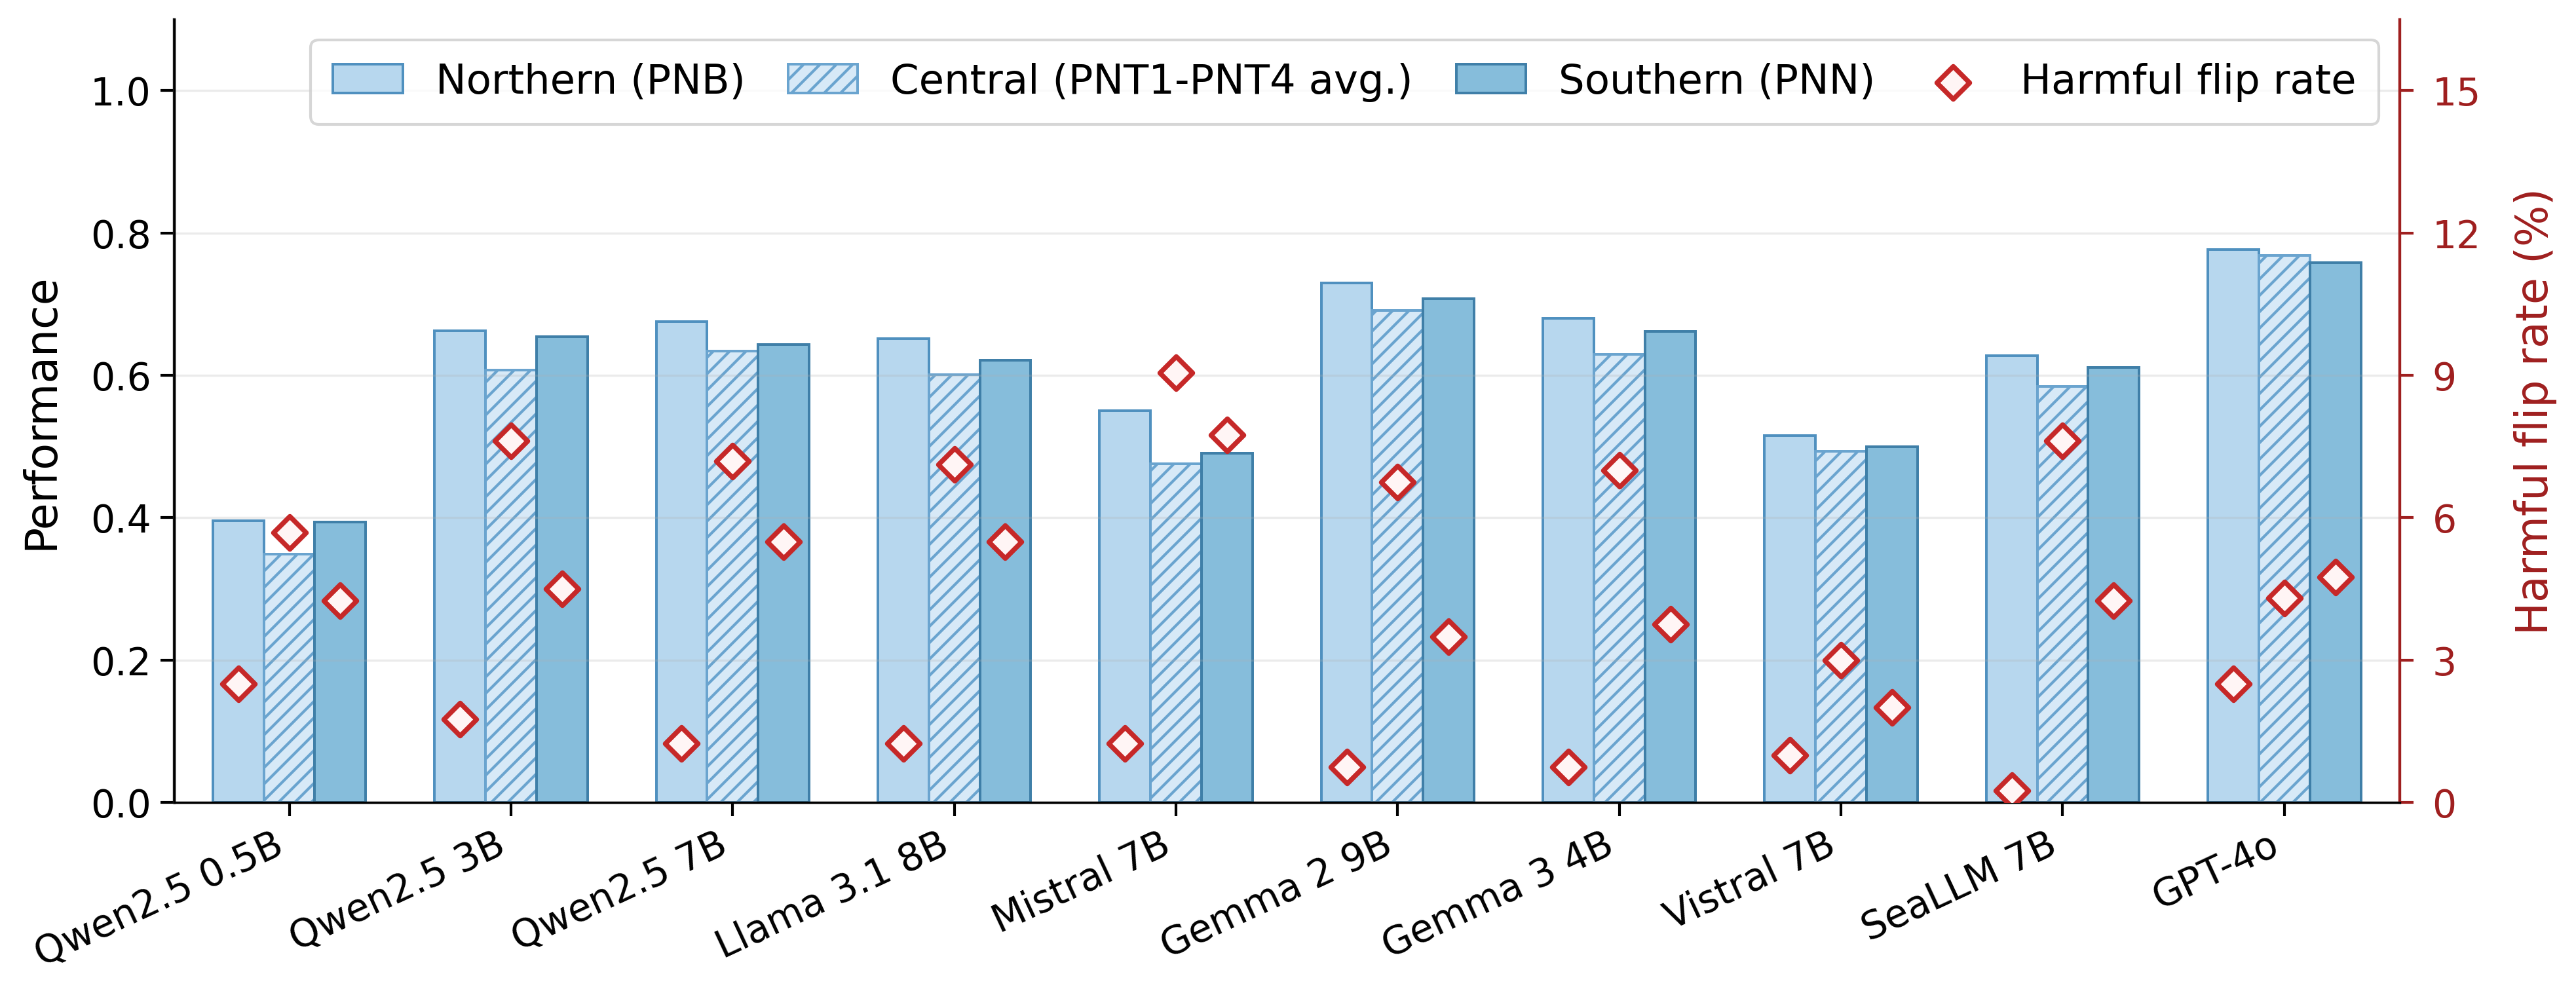

In [ ]:
plot_table = model_dialect_table.copy()
if not plot_table.empty:
    plot_table['model_slug'] = MODEL_ORDER
    northern = plot_table['PNB'].fillna(0.0).to_numpy()
    central = plot_table[['PNT1', 'PNT2', 'PNT3', 'PNT4']].mean(axis=1, skipna=True).fillna(0.0).to_numpy()
    southern = plot_table['PNN'].fillna(0.0).to_numpy()
else:
    northern = np.zeros(len(MODEL_ORDER))
    central = np.zeros(len(MODEL_ORDER))
    southern = np.zeros(len(MODEL_ORDER))

if pair_df.empty:
    region_flip = pd.DataFrame(np.nan, index=MODEL_ORDER, columns=['Northern', 'Central', 'Southern'])
else:
    tmp = pair_df.copy()
    tmp['region'] = tmp['variant'].map(REGION_MAP)
    region_flip = (
        tmp.dropna(subset=['region'])
        .groupby(['model_slug', 'region'], observed=False)['harmful_flip']
        .mean()
        .unstack('region')
        .reindex(index=MODEL_ORDER, columns=['Northern', 'Central', 'Southern'])
    )

x = np.arange(len(MODEL_ORDER))
width = 0.23
fig, ax = plt.subplots(figsize=(13.2, 5.15))
ax2 = ax.twinx()
bar_specs = [
    ('Northern', x - width, northern, '#b7d7ee', '#4f90bf', None, 'Northern (PNB)'),
    ('Central', x, central, '#d7e9f7', '#6aa4cf', '////', 'Central (PNT1-PNT4 avg.)'),
    ('Southern', x + width, southern, '#86bddb', '#3f7fa8', None, 'Southern (PNN)'),
]
max_flip_pp = 0.0
for region, xpos, values, color, edge, hatch, label in bar_specs:
    ax.bar(xpos, values, width=width, color=color, edgecolor=edge, linewidth=0.95, hatch=hatch, label=label)
    flips = region_flip[region].to_numpy(dtype=float) if region in region_flip else np.full(len(MODEL_ORDER), np.nan)
    flip_pp = flips * 100
    valid = pd.notna(flip_pp)
    if np.any(valid):
        max_flip_pp = max(max_flip_pp, float(np.nanmax(flip_pp[valid])))
        ax2.scatter(xpos[valid], flip_pp[valid], marker='D', s=72, facecolors='#fff5f5', edgecolors='#c62828', linewidths=1.8, zorder=5)

headroom_ratio = 1.10
ax.set_ylim(0, 1.0 * headroom_ratio)
ax.set_yticks(np.arange(0.0, 1.001, 0.2))
ax.set_ylabel('Performance', fontsize=16, labelpad=10)
right_tick_max = max(15.0, np.ceil((max_flip_pp * 1.25) / 5.0) * 5.0)
ax2.set_ylim(0, right_tick_max * headroom_ratio)
ax2.set_yticks(np.linspace(0, right_tick_max, 6))
ax2.set_ylabel('Harmful flip rate (%)', color='#9f1f1f', fontsize=16, labelpad=12)
ax.tick_params(axis='both', labelsize=14, length=5, width=1.0)
ax2.tick_params(axis='y', colors='#9f1f1f', labelsize=14, direction='out', length=5, width=1.0, pad=7)
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_color('#9f1f1f')
ax2.spines['right'].set_linewidth(1.05)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_color('#222222')
ax.spines['left'].set_linewidth(1.05)
ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax.grid(axis='y', which='major', alpha=0.25, linewidth=0.8)
ax2.grid(False)
ax.set_xticks(x, [MODEL_LABELS[m] for m in MODEL_ORDER], rotation=25, ha='right')
bar_handles, bar_labels = ax.get_legend_handles_labels()
flip_handle = ax2.scatter([], [], marker='D', s=72, facecolors='#fff5f5', edgecolors='#c62828', linewidths=1.8, label='Harmful flip rate')
ax.legend(
    bar_handles + [flip_handle],
    bar_labels + ['Harmful flip rate'],
    loc='upper right',
    frameon=True,
    ncol=4,
    fontsize=15,
    handlelength=1.7,
    columnspacing=1.05,
    borderpad=0.55,
)
ax.margins(x=0.018)
fig.tight_layout()
save_direct_figure(fig, 'paper_figure_model_performance')


## Analysis 3: Dialect-Specific Performance Drop

The table summarizes each model-dialect performance/drop pair. The heatmap shows paired performance drops in percentage points for every model and dialect.

In [ ]:
if pair_df.empty:
    dialect_summary = pd.DataFrame(columns=['model_slug', 'variant', 'dialect_performance', 'mean_drop', 'harmful_flip_rate', 'beneficial_flip_rate', 'prediction_flip_rate', 'n'])
else:
    dialect_summary = (
        pair_df.groupby(['model_slug', 'variant'], observed=False)
        .agg(
            dialect_performance=('score', 'mean'),
            mean_drop=('performance_drop', 'mean'),
            harmful_flip_rate=('harmful_flip', 'mean'),
            beneficial_flip_rate=('beneficial_flip', 'mean'),
            prediction_flip_rate=('prediction_flip', 'mean'),
            n=('id', 'size'),
        )
        .reindex(pd.MultiIndex.from_product([MODEL_ORDER, EXPECTED_DIALECTS], names=['model_slug', 'variant']))
        .reset_index()
    )
dialect_summary['model_short'] = dialect_summary['model_slug'].map(MODEL_LABELS)
dialect_table = dialect_summary[['model_short', 'variant', 'dialect_performance', 'mean_drop', 'harmful_flip_rate', 'beneficial_flip_rate', 'prediction_flip_rate', 'n']].rename(columns={
    'model_short': 'Model',
    'variant': 'Dialect',
    'dialect_performance': 'Performance',
    'mean_drop': 'Drop',
    'harmful_flip_rate': 'Harmful flip',
    'beneficial_flip_rate': 'Beneficial flip',
    'prediction_flip_rate': 'Prediction flip',
    'n': 'n',
})
formatted_dialect_table = dialect_table.copy()
for col in ['Performance', 'Drop', 'Harmful flip', 'Beneficial flip', 'Prediction flip']:
    formatted_dialect_table[col] = formatted_dialect_table[col].map(pct_or_dash)
formatted_dialect_table['n'] = formatted_dialect_table['n'].map(lambda x: '-' if pd.isna(x) or int(x) == 0 else str(int(x)))
save_direct_table(formatted_dialect_table, 'table_direct_prompting_by_dialect')
display(formatted_dialect_table)


wrote ..\paper_artifacts\direct_prompting\table_direct_prompting_by_dialect.csv
wrote ..\paper_artifacts\direct_prompting\table_direct_prompting_by_dialect.tex


,Model,Dialect,Performance,Drop,Harmful flip,Beneficial flip,Prediction flip,n
0,Qwen2.5 0.5B,PNB,39.6,1.4,2.5,0.8,9.0,400
1,Qwen2.5 0.5B,PNN,39.4,1.6,4.2,2.8,20.5,400
2,Qwen2.5 0.5B,PNT1,36.8,4.1,5.8,2.5,21.0,400
3,Qwen2.5 0.5B,PNT2,33.9,7.1,5.2,1.8,30.5,400
4,Qwen2.5 0.5B,PNT3,31.8,9.2,7.2,2.0,35.8,400
5,Qwen2.5 0.5B,PNT4,37.1,3.8,4.5,1.8,25.5,400
6,Qwen2.5 3B,PNB,66.3,0.5,1.8,1.2,6.2,400
7,Qwen2.5 3B,PNN,65.4,1.4,4.5,3.5,14.2,400
8,Qwen2.5 3B,PNT1,64.2,2.6,4.8,2.2,11.5,400
9,Qwen2.5 3B,PNT2,60.0,6.8,8.0,3.2,23.2,400


**Note.** `paper_figure_dialect_robustness_fingerprint` reports paired score differences: for each model and dialect, it averages `standard score for the same sample` minus `dialect score`. This is why a heatmap cell can differ from `Standard - dialect` read directly from the absolute-score table.


wrote ..\paper_artifacts\direct_prompting\paper_figure_dialect_robustness_fingerprint.png
wrote ..\paper_artifacts\direct_prompting\paper_figure_dialect_robustness_fingerprint.pdf


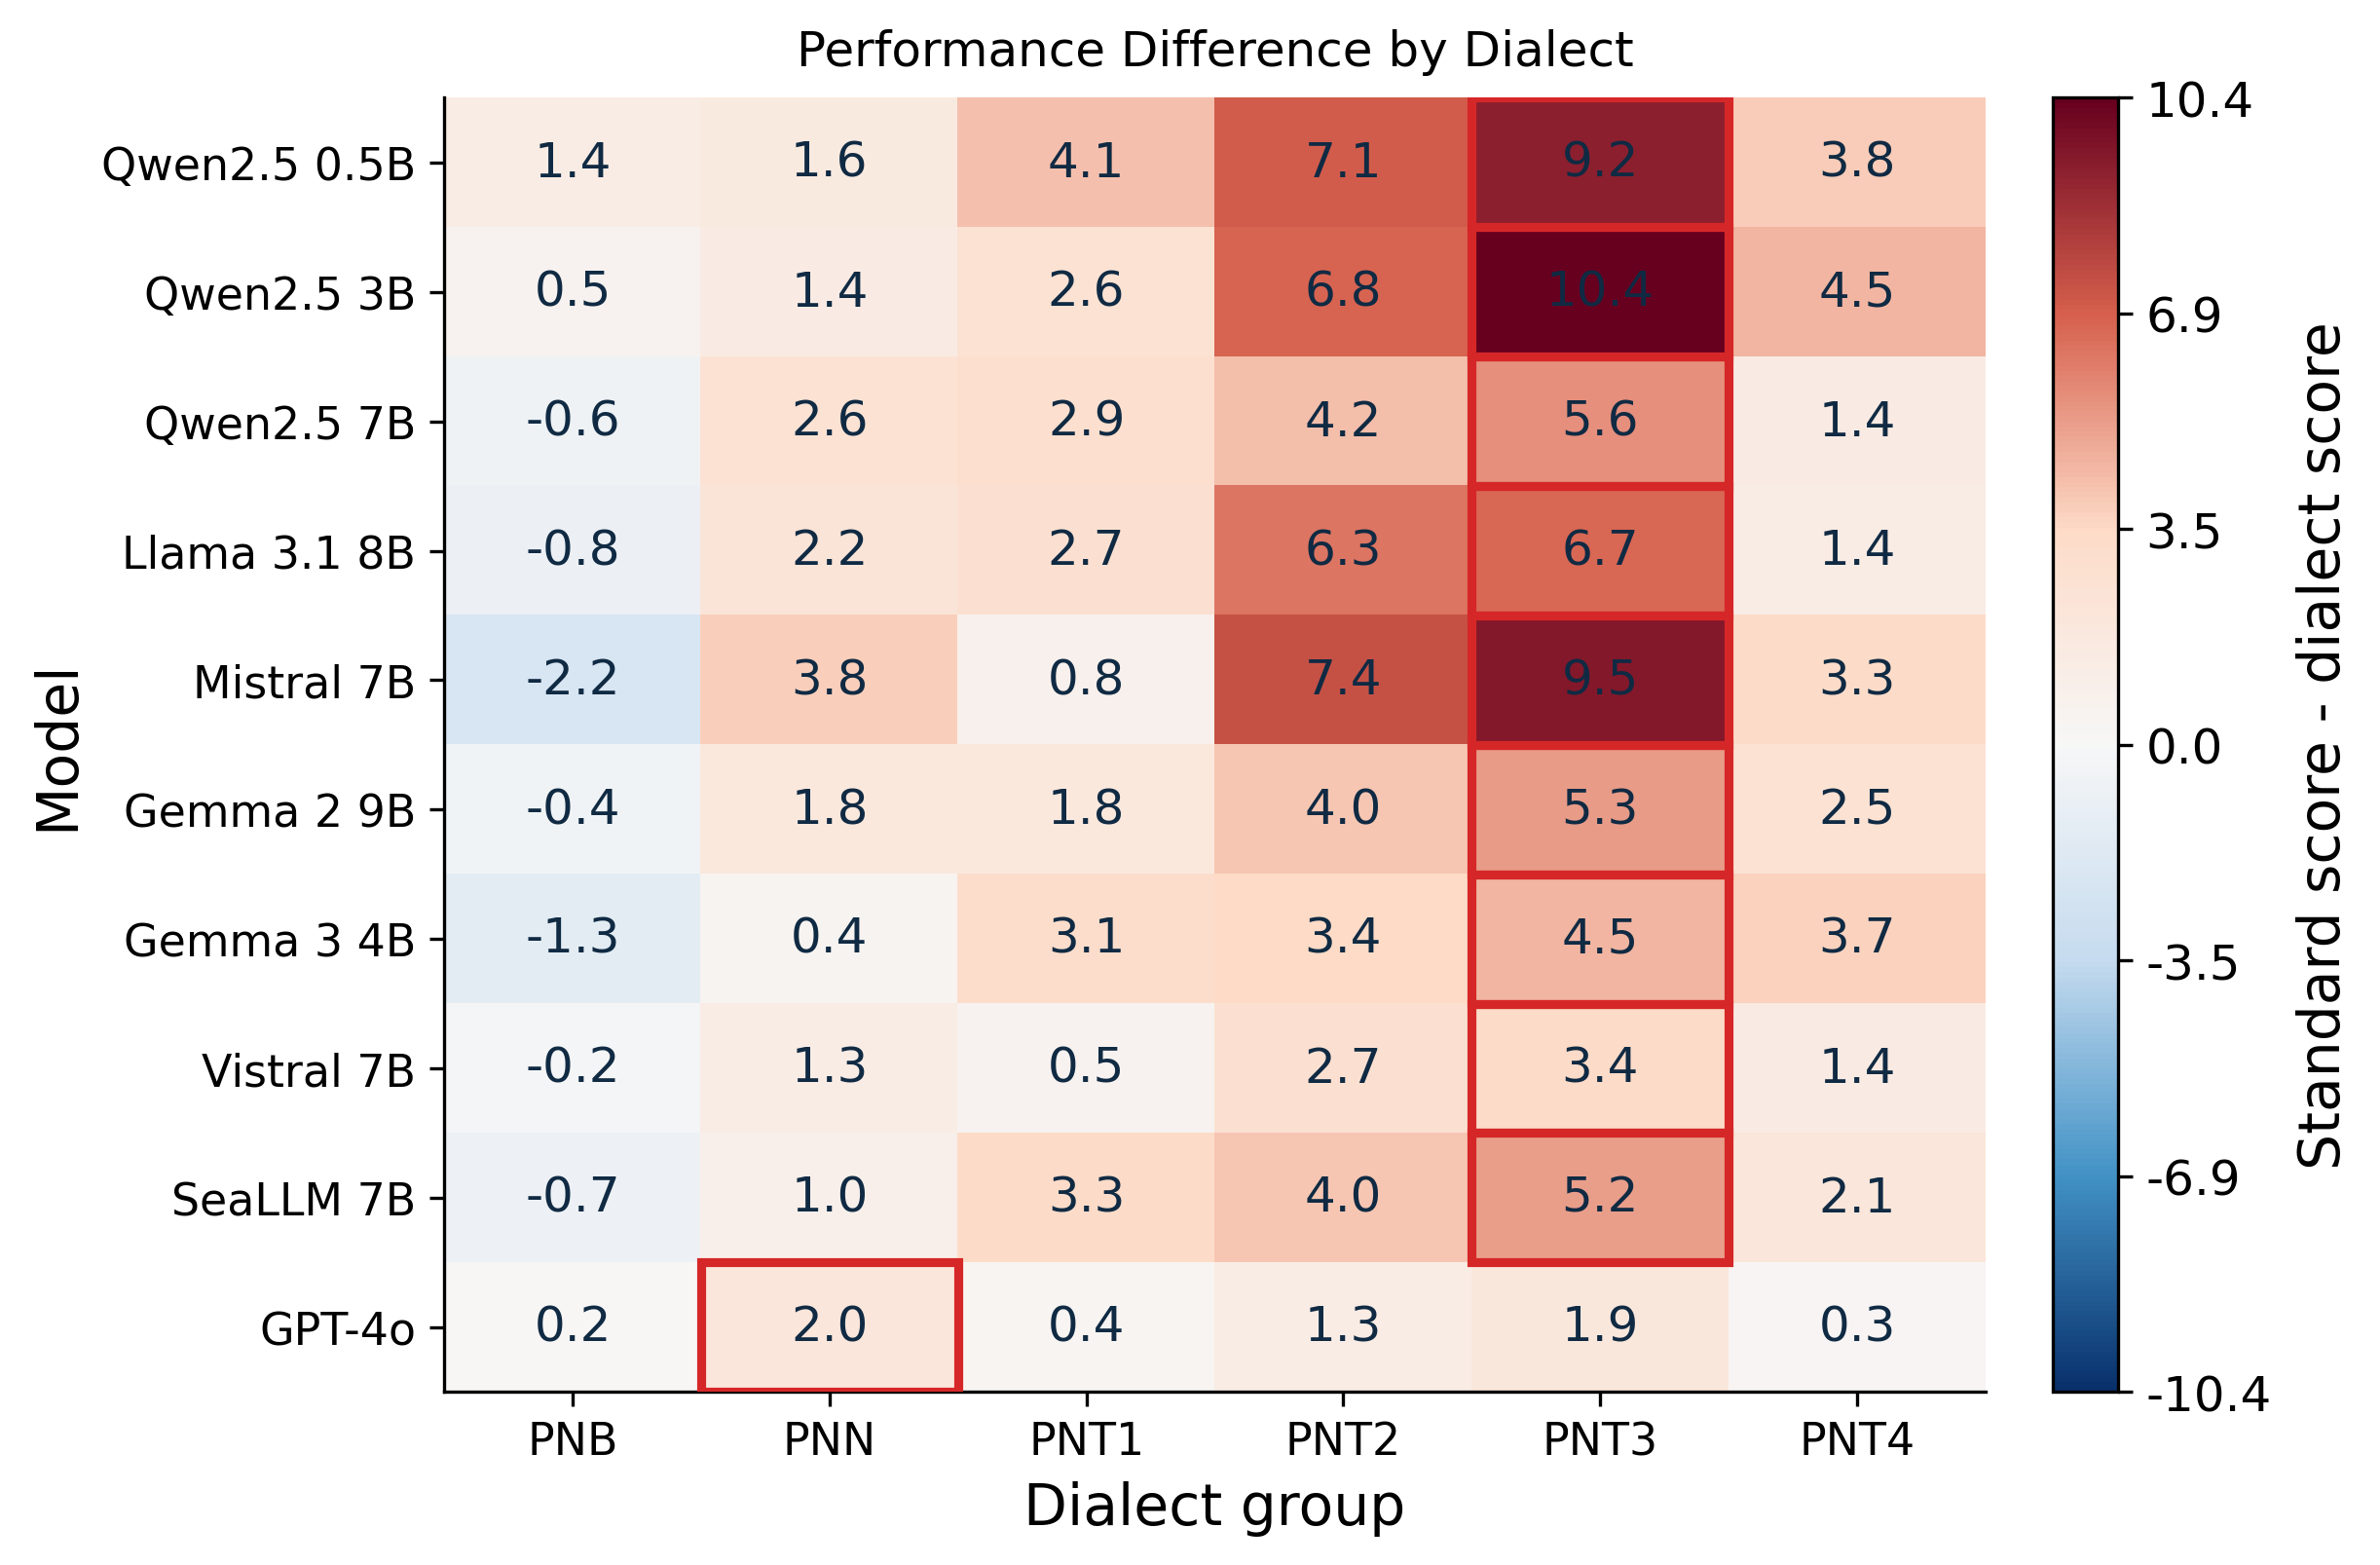

In [ ]:
# NOTE: This heatmap reports paired score differences by dialect: mean over rows with this dialect of (standard score for the same model/task/id - dialect score). For example, Llama/PNB uses the standard score only for the same IDs that have PNB, so it can differ from subtracting the table's overall Standard column.

if pair_df.empty:
    fingerprint = pd.DataFrame(
        index=MODEL_ORDER,
        columns=EXPECTED_DIALECTS
    )
else:
    dialect_fp = (
        pair_df.groupby(
            ['model_slug', 'variant'],
            observed=False
        )
        .agg(mean_drop=('performance_drop', 'mean'))
        .reset_index()
    )

    fingerprint = (
        dialect_fp
        .pivot(
            index='model_slug',
            columns='variant',
            values='mean_drop'
        )
        .reindex(
            index=MODEL_ORDER,
            columns=EXPECTED_DIALECTS
        )
        * 100
    )


fig, ax = plt.subplots(figsize=(8.2, 5.45))

plot_vals = fingerprint.astype(float)
masked_plot_vals = np.ma.masked_invalid(plot_vals.to_numpy(dtype=float))


# =========================================================
# Diverging colour scale:
# negative = blue, zero = white, positive = red
# =========================================================
finite_values = plot_vals.to_numpy(dtype=float)
finite_values = finite_values[np.isfinite(finite_values)]

if finite_values.size:
    max_abs_value = max(
        1.0,
        float(np.nanmax(np.abs(finite_values)))
    )
else:
    max_abs_value = 1.0


# Symmetric colour range around zero
vmin = -max_abs_value
vmax = max_abs_value


blue_white_red = matplotlib.colors.LinearSegmentedColormap.from_list(
    'blue_white_red',
    [
        '#08306b',  # strong negative: dark blue
        '#4292c6',  # negative: blue
        '#c6dbef',  # slightly negative: light blue
        '#f7f7f7',  # zero: white
        '#fddbc7',  # slightly positive: light red
        '#d6604d',  # positive: red
        '#67001f',  # strong positive: dark red
    ],
    N=256,
)


norm = matplotlib.colors.TwoSlopeNorm(
    vmin=vmin,
    vcenter=0.0,
    vmax=vmax,
)


blue_white_red.set_bad('#f2f2f2')

im = ax.imshow(
    masked_plot_vals,
    cmap=blue_white_red,
    norm=norm,
    aspect='auto',
)


ax.set_title('Performance Difference by Dialect', fontsize=12, pad=8)
ax.set_xlabel('Dialect group', fontsize=14)
ax.set_ylabel('Model', fontsize=14)
ax.set_xticks(
    np.arange(len(EXPECTED_DIALECTS)),
    EXPECTED_DIALECTS
)

ax.set_yticks(
    np.arange(len(MODEL_ORDER)),
    [MODEL_LABELS[m] for m in MODEL_ORDER]
)

ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)
# =========================================================
# Display values inside cells
# =========================================================
for i, model in enumerate(MODEL_ORDER):
    for j, dialect in enumerate(EXPECTED_DIALECTS):
        val = fingerprint.loc[model, dialect]

        ax.text(
            j,
            i,
            '-' if pd.isna(val) else f'{val:.1f}',
            ha='center',
            va='center',
            fontsize=12,
            color='#102a43',
        )


# =========================================================
# Red border around the largest drop in each model row
# =========================================================
for i, model in enumerate(MODEL_ORDER):
    row_values = fingerprint.loc[model].to_numpy(dtype=float)

    if np.all(np.isnan(row_values)):
        continue

    largest_drop = np.nanmax(row_values)

    largest_drop_indices = np.where(
        np.isclose(
            row_values,
            largest_drop,
            equal_nan=False
        )
    )[0]

    for j in largest_drop_indices:
        border = matplotlib.patches.Rectangle(
            (j - 0.5, i - 0.5),
            width=1,
            height=1,
            fill=False,
            edgecolor='#d62728',
            linewidth=2.2,
            zorder=5,
        )

        ax.add_patch(border)


# =========================================================
# Colour bar
# =========================================================
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04,
)
cbar.set_label('Standard score - dialect score', fontsize=14, labelpad=6)


# Symmetric colour-bar ticks around zero
cbar_ticks = np.linspace(
    -max_abs_value,
    max_abs_value,
    7,
)

cbar.set_ticks(cbar_ticks)

cbar.ax.set_yticklabels([
    f'{tick:.1f}'
    for tick in cbar_ticks
])

cbar.set_label('Standard score - dialect score', fontsize=14, labelpad=6)
cbar.ax.tick_params(labelsize=12)
fig.tight_layout()

save_direct_figure(
    fig,
    'paper_figure_dialect_robustness_fingerprint'
)

## Analysis 4: Dialect Performance Radar

The table and radar figure report each model's average performance on the six dialect groups. Each value is the mean task score for that model on that dialect group; QA contributes token-level F1, while MCQA, NLI, and Sentiment contribute accuracy.

In [ ]:
radar_dialects = ['PNB', 'PNT1', 'PNT2', 'PNT3', 'PNT4', 'PNN']
radar_labels = ['PNB\n(North)', 'PNT1', 'PNT2', 'PNT3', 'PNT4', 'PNN\n(South)']

if pair_df.empty:
    radar_values = pd.DataFrame(index=MODEL_ORDER, columns=radar_dialects, dtype=float)
    radar_counts = pd.DataFrame(index=MODEL_ORDER, columns=radar_dialects, dtype=float)
else:
    dialect_perf = (
        pair_df.groupby(['model_slug', 'variant'], observed=False)
        .agg(avg_performance=('score', 'mean'), n=('id', 'size'))
        .reset_index()
    )
    radar_values = (
        dialect_perf.pivot(index='model_slug', columns='variant', values='avg_performance')
        .reindex(index=MODEL_ORDER, columns=radar_dialects)
    )
    radar_counts = (
        dialect_perf.pivot(index='model_slug', columns='variant', values='n')
        .reindex(index=MODEL_ORDER, columns=radar_dialects)
    )

radar_table = radar_values.reset_index()
radar_table['Model'] = radar_table['model_slug'].map(MODEL_LABELS)
radar_table = radar_table[['Model'] + radar_dialects]
formatted_radar_table = radar_table.copy()
for col in radar_dialects:
    formatted_radar_table[col] = formatted_radar_table[col].map(pct_or_dash)
save_direct_table(formatted_radar_table, 'paper_table_confidence_robustness')
display(formatted_radar_table)


wrote ..\paper_artifacts\direct_prompting\paper_table_confidence_robustness.csv
wrote ..\paper_artifacts\direct_prompting\paper_table_confidence_robustness.tex


variant,Model,PNB,PNT1,PNT2,PNT3,PNT4,PNN
0,Qwen2.5 0.5B,39.6,36.8,33.9,31.8,37.1,39.4
1,Qwen2.5 3B,66.3,64.2,60.0,56.4,62.3,65.4
2,Qwen2.5 7B,67.5,64.0,62.7,61.3,65.5,64.4
3,Llama 3.1 8B,65.1,61.6,58.0,57.6,63.0,62.1
4,Mistral 7B,55.0,52.0,45.4,43.4,49.5,49.0
5,Gemma 2 9B,73.0,70.7,68.5,67.3,70.0,70.7
6,Gemma 3 4B,68.0,63.5,63.2,62.1,62.9,66.2
7,Vistral 7B,51.5,50.8,48.6,47.9,49.9,50.0
8,SeaLLM 7B,62.8,58.7,58.0,56.9,60.0,61.1
9,GPT-4o,77.7,77.4,76.6,75.9,77.5,75.8


wrote ..\paper_artifacts\direct_prompting\paper_figure_model_confidence_robustness.png
wrote ..\paper_artifacts\direct_prompting\paper_figure_model_confidence_robustness.pdf


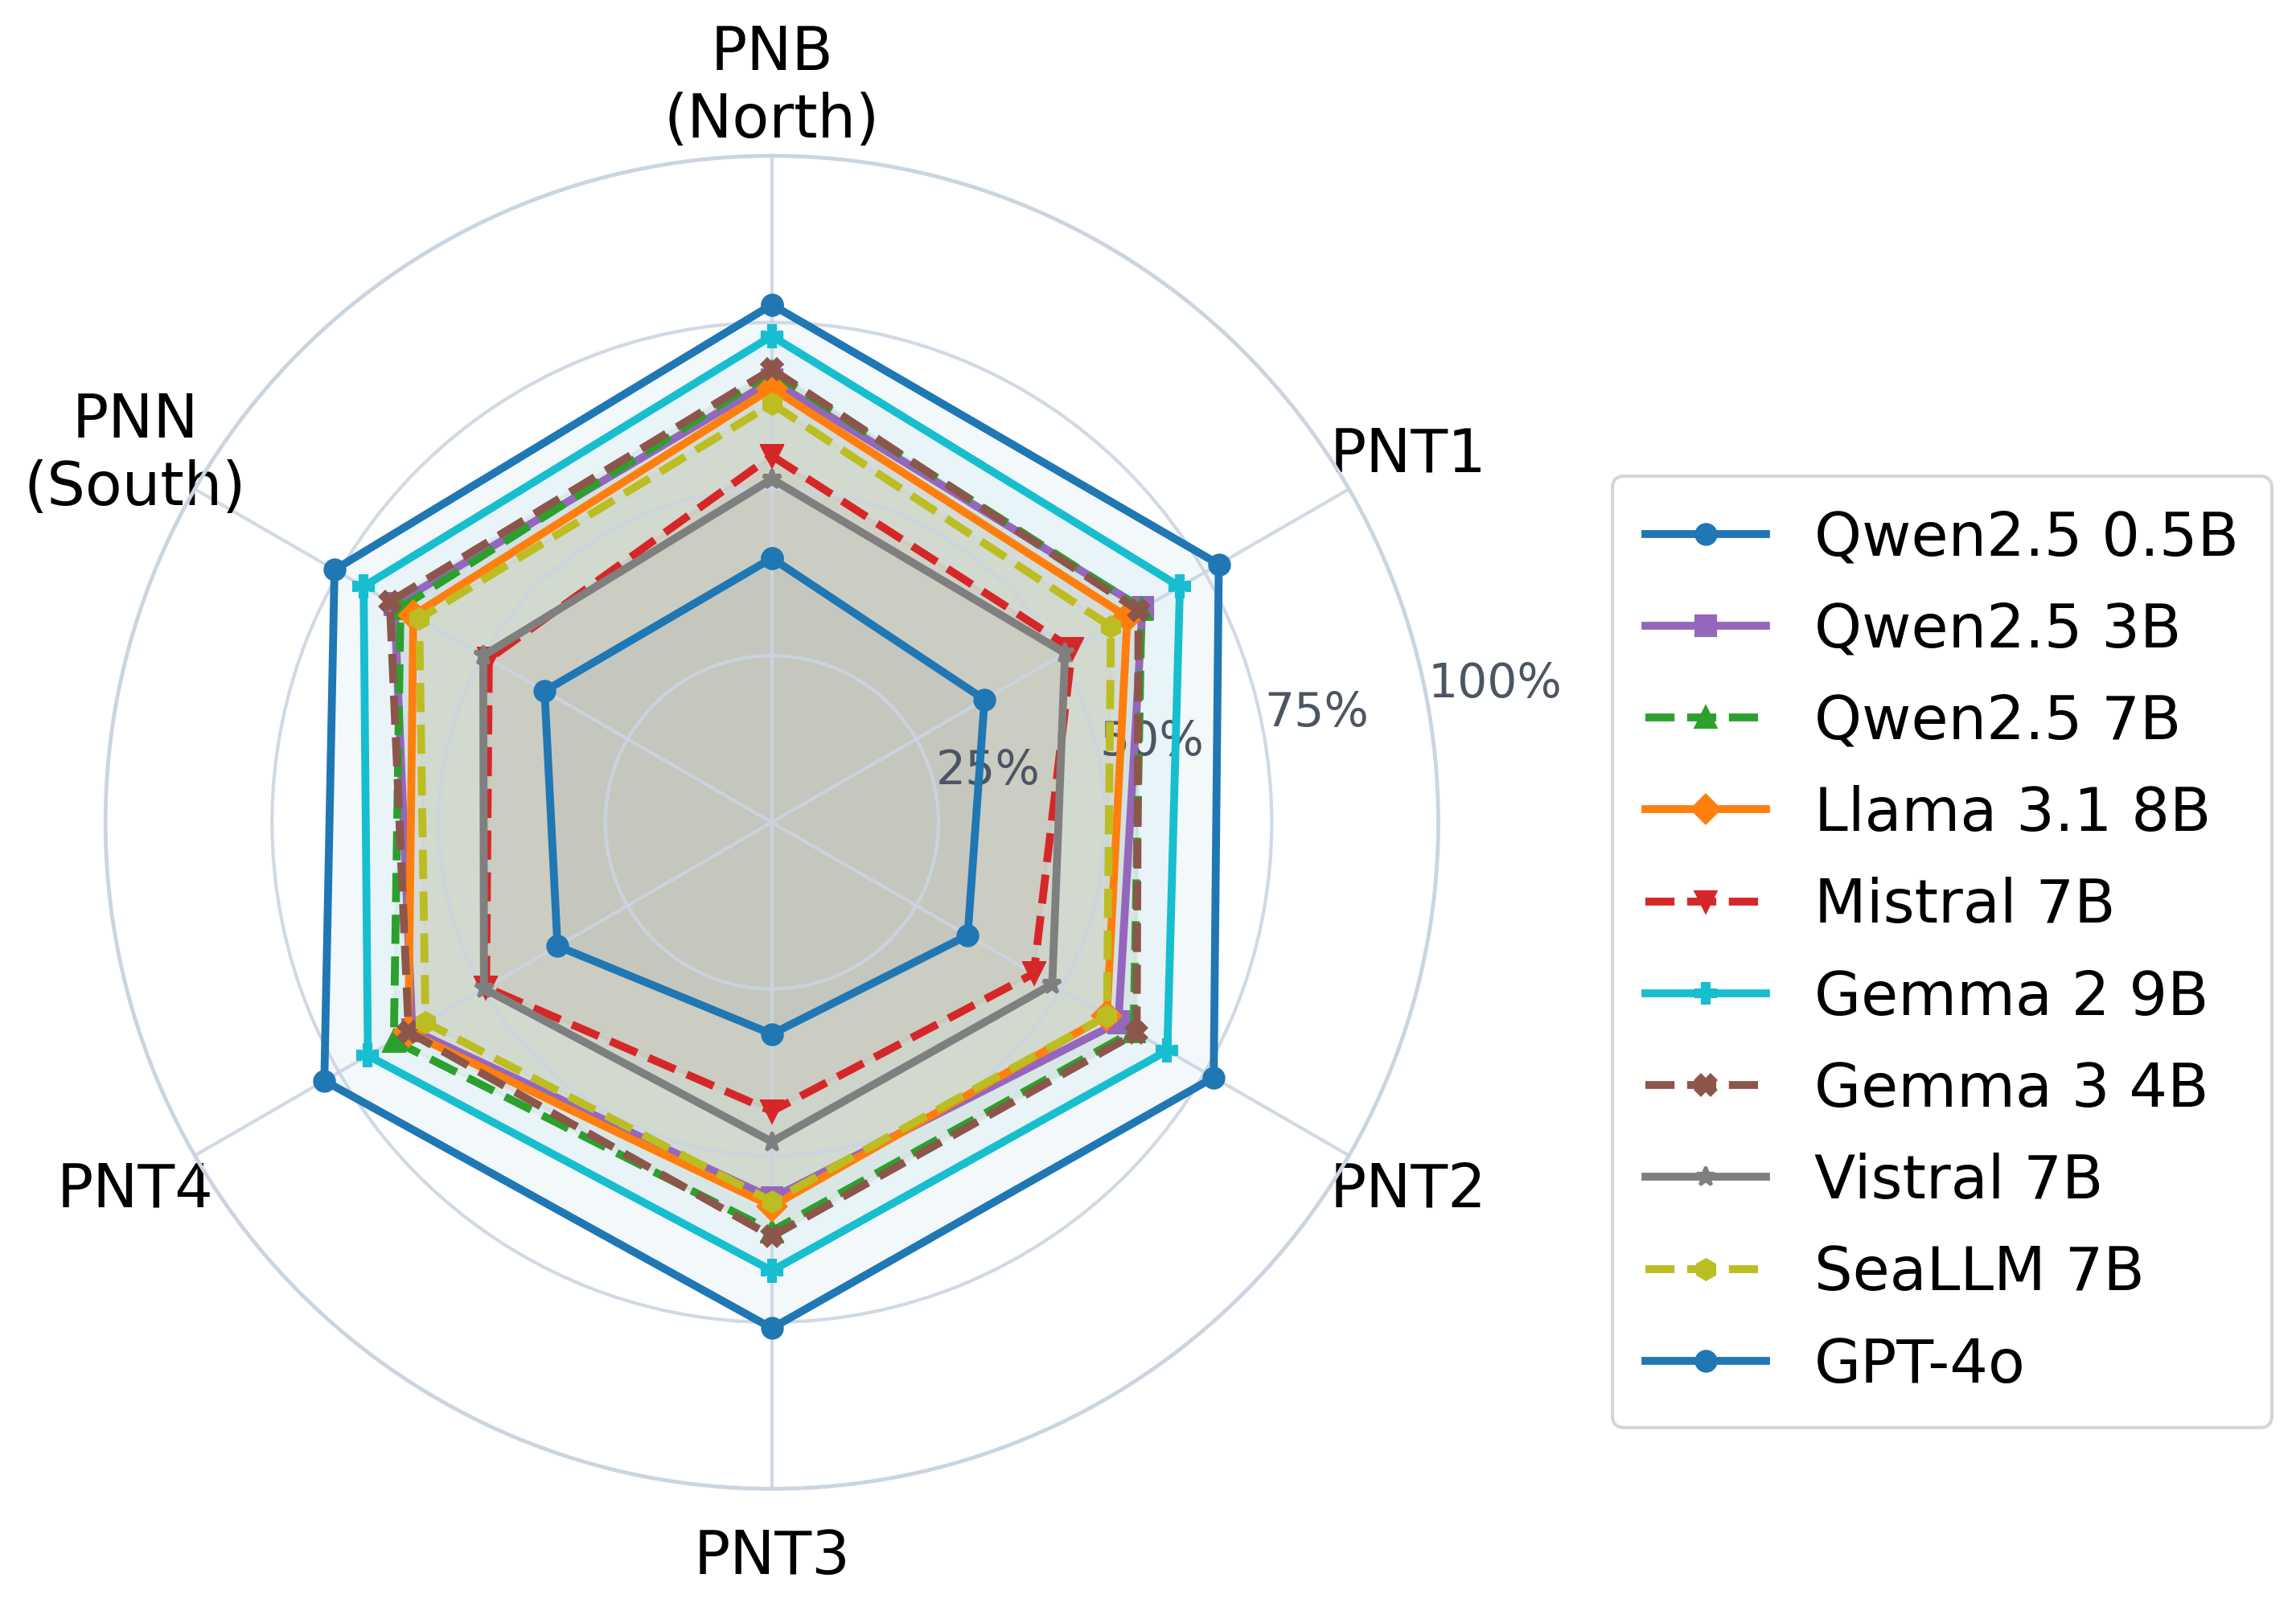

In [ ]:
angles = np.linspace(0, 2 * np.pi, len(radar_dialects), endpoint=False)
angles_closed = np.concatenate([angles, [angles[0]]])

# Increase width to reserve space for the legend on the right
fig = plt.figure(figsize=(9.2, 6.35))
ax = fig.add_subplot(111, polar=True)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles, radar_labels)
ax.tick_params(axis='x', labelsize=18, pad=10)

ax.set_ylim(0, 1.0)
ax.set_yticks([0.25, 0.50, 0.75, 1.0])
ax.set_yticklabels(
    ['25%', '50%', '75%', '100%'],
    fontsize=14,
    color='#4b5563'
)
ax.set_rlabel_position(80)

ax.grid(color='#cbd5e1', linewidth=1.0, alpha=0.9)
ax.spines['polar'].set_color('#cbd5e1')
ax.spines['polar'].set_linewidth(1.15)

style_cycle = [
    ('#1f77b4', '-', 'o'),
    ('#9467bd', '-', 's'),
    ('#2ca02c', '--', '^'),
    ('#ff7f0e', '-', 'D'),
    ('#d62728', '--', 'v'),
    ('#17becf', '-', 'P'),
    ('#8c564b', '--', 'X'),
    ('#7f7f7f', '-', '*'),
    ('#bcbd22', '--', 'h'),
]

handles = []

for idx, model in enumerate(MODEL_ORDER):
    vals = (
        radar_values.loc[model]
        if model in radar_values.index
        else pd.Series(index=radar_dialects, dtype=float)
    )

    if vals.notna().sum() == 0:
        continue

    plot_vals = vals.astype(float).to_numpy()
    plot_vals = np.nan_to_num(plot_vals, nan=0.0)
    plot_vals_closed = np.concatenate([plot_vals, [plot_vals[0]]])

    color, linestyle, marker = style_cycle[idx % len(style_cycle)]

    handle, = ax.plot(
        angles_closed,
        plot_vals_closed,
        color=color,
        linestyle=linestyle,
        linewidth=2.35,
        marker=marker,
        markersize=5.8,
        label=MODEL_LABELS.get(model, model),
    )

    ax.fill(
        angles_closed,
        plot_vals_closed,
        color=color,
        alpha=0.05
    )

    handles.append(handle)

if handles:
    fig.legend(
        handles=handles,
        loc='lower left',
        bbox_to_anchor=(0.76, 0.10),
        frameon=True,
        ncol=1,
        fontsize=18,
        handlelength=2.0,
        borderpad=0.55,
        labelspacing=0.55,
    )

# Reserve the right side for the legend
fig.subplots_adjust(
    left=0.06,
    right=0.73,
    top=0.95,
    bottom=0.08
)

save_direct_figure(
    fig,
    'paper_figure_model_confidence_robustness'
)

## Analysis 4b: Central Dialect Task Radar

This radar figure reports each model's average performance on the Central dialect variants (PNT1-PNT4) across the four tasks. Each axis is one task; QA uses token-level F1, while MCQA, NLI, and Sentiment use accuracy.


wrote ..\paper_artifacts\direct_prompting\paper_table_central_task_performance_radar.csv
wrote ..\paper_artifacts\direct_prompting\paper_table_central_task_performance_radar.tex


task,Model,MCQA,NLI,QA,Sent.
0,Qwen2.5 0.5B,59.2,33.0,25.4,22.0
1,Qwen2.5 3B,86.5,53.8,60.7,42.0
2,Qwen2.5 7B,87.0,60.5,68.6,37.5
3,Llama 3.1 8B,81.8,46.0,75.5,37.0
4,Mistral 7B,70.0,48.2,37.5,34.5
5,Gemma 2 9B,94.0,60.2,81.2,41.0
6,Gemma 3 4B,87.2,50.0,73.6,41.0
7,Vistral 7B,86.8,18.2,60.4,31.8
8,SeaLLM 7B,87.8,44.0,65.7,36.2
9,GPT-4o,93.8,70.5,83.4,59.8


wrote ..\paper_artifacts\direct_prompting\paper_figure_central_task_performance_radar.png
wrote ..\paper_artifacts\direct_prompting\paper_figure_central_task_performance_radar.pdf


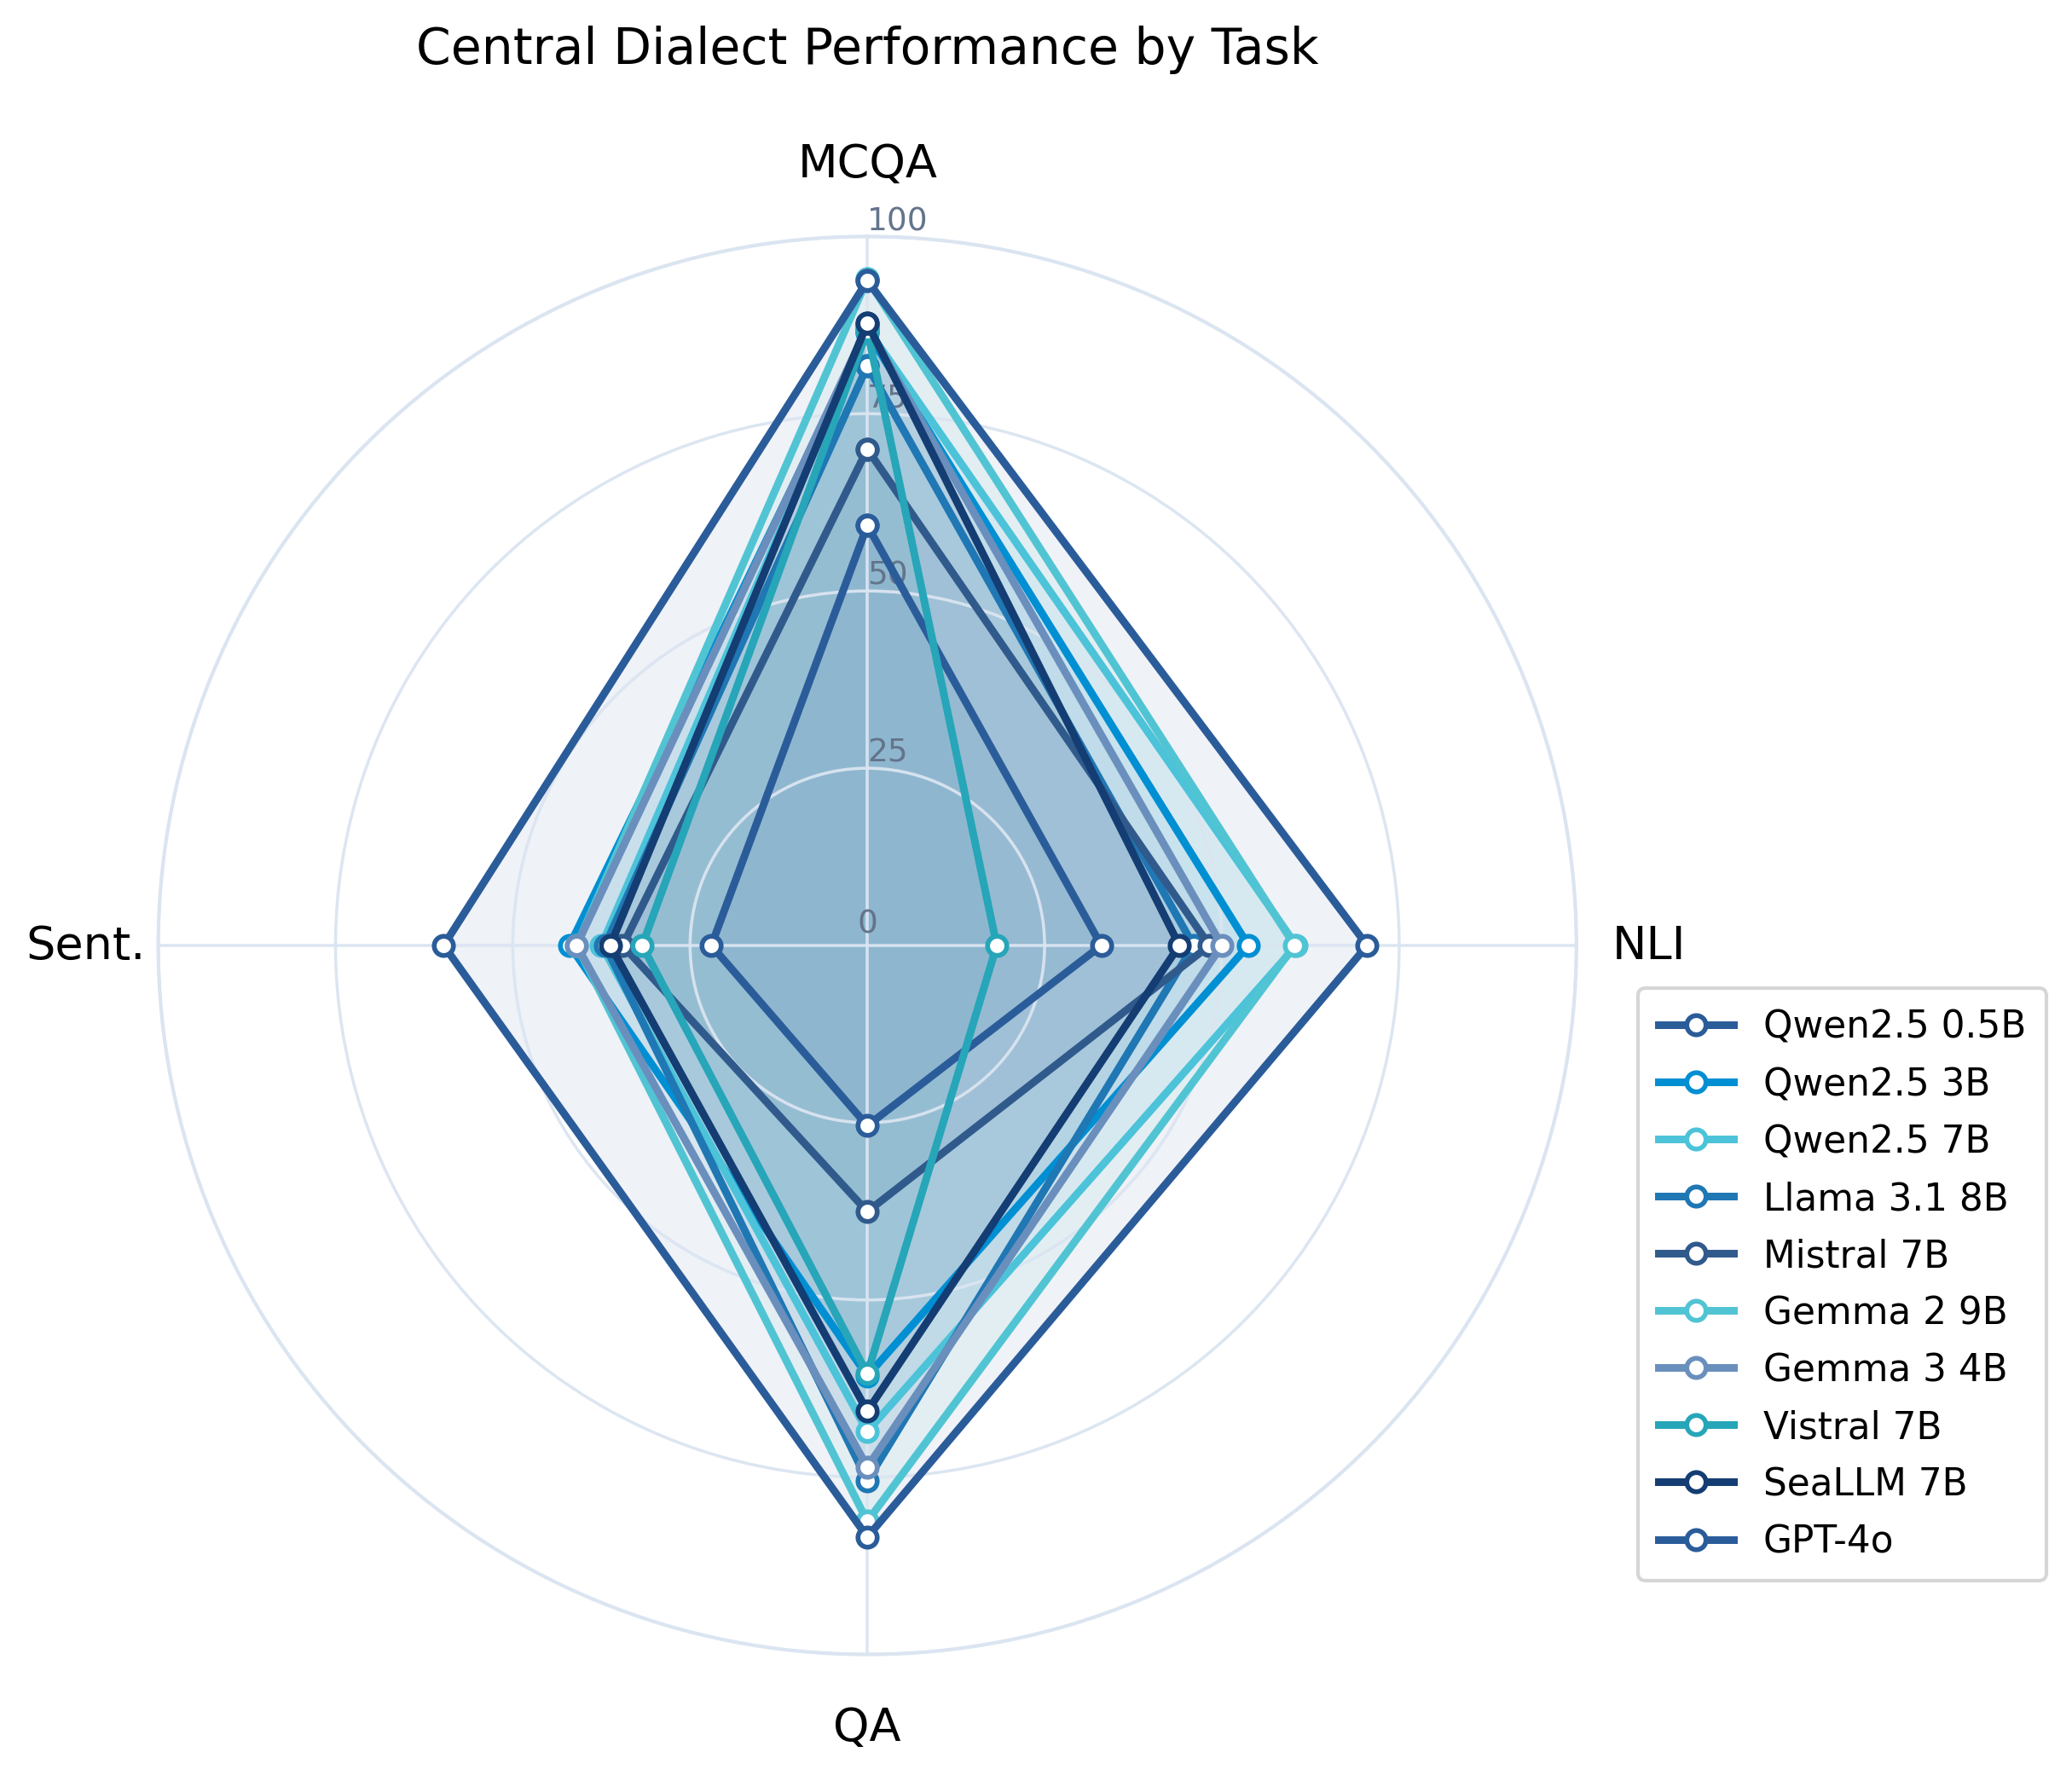

In [ ]:
CENTRAL_DIALECTS = ['PNT1', 'PNT2', 'PNT3', 'PNT4']
CENTRAL_TASK_RADAR_STEM = 'paper_table_central_task_performance_radar'
CENTRAL_TASK_RADAR_FIG_STEM = 'paper_figure_central_task_performance_radar'

if pair_df.empty:
    central_task_values = pd.DataFrame(index=MODEL_ORDER, columns=TASK_MATRIX_TASKS, dtype=float)
    central_task_counts = pd.DataFrame(index=MODEL_ORDER, columns=TASK_MATRIX_TASKS, dtype=float)
else:
    central_task_perf = (
        pair_df[pair_df['variant'].isin(CENTRAL_DIALECTS)]
        .groupby(['model_slug', 'task'], observed=False)
        .agg(avg_performance=('score', 'mean'), n=('id', 'size'))
        .reset_index()
    )
    central_task_values = (
        central_task_perf.pivot(index='model_slug', columns='task', values='avg_performance')
        .reindex(index=MODEL_ORDER, columns=TASK_MATRIX_TASKS)
    )
    central_task_counts = (
        central_task_perf.pivot(index='model_slug', columns='task', values='n')
        .reindex(index=MODEL_ORDER, columns=TASK_MATRIX_TASKS)
    )

central_task_table = central_task_values.reset_index()
central_task_table['Model'] = central_task_table['model_slug'].map(MODEL_LABELS)
central_task_table = central_task_table[['Model'] + TASK_MATRIX_TASKS]
central_task_table = central_task_table.rename(columns=TASK_MATRIX_LABELS)
formatted_central_task_table = central_task_table.copy()
for task_label in [TASK_MATRIX_LABELS[t] for t in TASK_MATRIX_TASKS]:
    formatted_central_task_table[task_label] = formatted_central_task_table[task_label].map(pct_or_dash)
save_direct_table(formatted_central_task_table, CENTRAL_TASK_RADAR_STEM)
display(formatted_central_task_table)

central_task_labels = [TASK_MATRIX_LABELS[t] for t in TASK_MATRIX_TASKS]
angles = np.linspace(0, 2 * np.pi, len(TASK_MATRIX_TASKS), endpoint=False)
angles_closed = np.concatenate([angles, [angles[0]]])

fig = plt.figure(figsize=(8.4, 7.1))
ax = fig.add_subplot(111, polar=True)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles, central_task_labels)
ax.tick_params(axis='x', labelsize=13, pad=10)

ax.set_ylim(0, 1.0)
ax.set_yticks([0.25, 0.50, 0.75, 1.0])
ax.set_yticklabels(['25', '50', '75', '100'], fontsize=9, color='#64748b')
ax.set_rlabel_position(0)
ax.text(0, 0.03, '0', ha='center', va='center', fontsize=9, color='#64748b')

ax.grid(color='#dbe5f1', linewidth=0.85, alpha=0.95)
ax.spines['polar'].set_color('#dbe5f1')
ax.spines['polar'].set_linewidth(1.0)
ax.set_title('Central Dialect Performance by Task', fontsize=14, pad=22)

style_cycle = [
    '#2b5c9a',
    '#008fd3',
    '#4cc3d9',
    '#1f77b4',
    '#315a8c',
    '#51c4d3',
    '#6a8fbd',
    '#26a6b8',
    '#143d73',
]

handles = []
for idx, model in enumerate(MODEL_ORDER):
    vals = (
        central_task_values.loc[model]
        if model in central_task_values.index
        else pd.Series(index=TASK_MATRIX_TASKS, dtype=float)
    )

    if vals.notna().sum() == 0:
        continue

    plot_vals = vals.astype(float).to_numpy()
    plot_vals = np.nan_to_num(plot_vals, nan=0.0)
    plot_vals_closed = np.concatenate([plot_vals, [plot_vals[0]]])

    color = style_cycle[idx % len(style_cycle)]
    handle, = ax.plot(
        angles_closed,
        plot_vals_closed,
        color=color,
        linestyle='-',
        linewidth=2.15,
        marker='o',
        markersize=5.4,
        markerfacecolor='white',
        markeredgewidth=1.35,
        label=MODEL_LABELS.get(model, model),
    )
    ax.fill(angles_closed, plot_vals_closed, color=color, alpha=0.075)
    handles.append(handle)

if handles:
    fig.legend(
        handles=handles,
        loc='lower left',
        bbox_to_anchor=(0.74, 0.12),
        frameon=True,
        ncol=1,
        fontsize=10.5,
        handlelength=2.0,
        borderpad=0.55,
        labelspacing=0.55,
    )

fig.subplots_adjust(left=0.06, right=0.72, top=0.88, bottom=0.08)
save_direct_figure(fig, CENTRAL_TASK_RADAR_FIG_STEM)


In [ ]:
if summary.empty:
    task_component_table = pd.DataFrame(
        index=pd.MultiIndex.from_product([MODEL_ORDER, TASK_ORDER], names=['model_slug', 'task'])
    ).reset_index()
    task_component_table['standard_performance'] = np.nan
    task_component_table['dialect_performance'] = np.nan
    task_component_table['mean_drop'] = np.nan
    task_component_table['dialect_n'] = np.nan
else:
    task_component_table = (
        summary.set_index(['model_slug', 'task'])
        .reindex(pd.MultiIndex.from_product([MODEL_ORDER, TASK_ORDER], names=['model_slug', 'task']))
        .reset_index()
    )

task_component_table['Model'] = task_component_table['model_slug'].map(MODEL_LABELS)
task_component_table['Task'] = task_component_table['task'].map(TASK_LABELS).fillna(task_component_table['task'].astype(str))
task_component_table = task_component_table.rename(columns={
    'standard_performance': 'Standard',
    'dialect_performance': 'Dialect mean',
    'mean_drop': 'Drop',
    'dialect_n': 'Dialect n',
})
task_component_table = task_component_table[
    ['Model', 'Task', 'Standard', 'Dialect mean', 'Drop', 'Dialect n']
]

formatted_task_component_table = task_component_table.copy()
for col in ['Standard', 'Dialect mean', 'Drop']:
    formatted_task_component_table[col] = formatted_task_component_table[col].map(pct_or_dash)
formatted_task_component_table['Dialect n'] = formatted_task_component_table['Dialect n'].map(
    lambda x: '-' if pd.isna(x) or int(x) == 0 else str(int(x))
)
save_direct_table(formatted_task_component_table, 'paper_table_task_performance_components')
display(formatted_task_component_table)


wrote ..\paper_artifacts\direct_prompting\paper_table_task_performance_components.csv
wrote ..\paper_artifacts\direct_prompting\paper_table_task_performance_components.tex


,Model,Task,Standard,Dialect mean,Drop,Dialect n
0,Qwen2.5 0.5B,MCQA,68.0,60.5,7.5,600
1,Qwen2.5 0.5B,NLI,33.0,33.0,0.0,600
2,Qwen2.5 0.5B,QA,38.9,29.8,9.2,600
3,Qwen2.5 0.5B,Sentiment,24.0,22.5,1.5,600
4,Qwen2.5 3B,MCQA,92.0,88.0,4.0,600
5,Qwen2.5 3B,NLI,55.0,54.3,0.7,600
6,Qwen2.5 3B,QA,69.2,62.7,6.4,600
7,Qwen2.5 3B,Sentiment,51.0,44.7,6.3,600
8,Qwen2.5 7B,MCQA,91.0,87.8,3.2,600
9,Qwen2.5 7B,NLI,64.0,61.2,2.8,600


## Analysis 5: Discussion Probes - Confidence Erosion and Normalizer Rescue

This discussion-oriented section moves beyond aggregate performance. First, it isolates rows where the model keeps the correct label under dialect prompting but loses confidence. Second, it exports hard dialect-sensitive cases for normalization and automatically computes a normalizer rescue table when normalized-direct outputs are available.

For the confidence analysis, all dialect variants are used. For the normalizer probe, a hard case is a model/sample pair that is correct in Standard Vietnamese but fails on at least half of the available dialect variants.

In [ ]:
CONF_DROP_MODEL_ORDER = [model for model in MODEL_ORDER if model != 'gpt_4o']

preserved_correct = pd.DataFrame()
if not pair_df.empty:
    preserved_correct = pair_df[
        (pair_df['standard_correct'] == 1.0)
        & (pair_df['correct'] == 1.0)
        & pair_df['standard_confidence'].notna()
        & pair_df['confidence'].notna()
        & (pair_df['model_slug'] != 'gpt_4o')
    ].copy()
    preserved_correct['large_confidence_drop'] = (preserved_correct['confidence_drop'] >= 0.10).astype(float)
    preserved_correct['confidence_drop_pos'] = preserved_correct['confidence_drop'].clip(lower=0)

if preserved_correct.empty:
    confidence_drop_model = pd.DataFrame(index=CONF_DROP_MODEL_ORDER, columns=[
        'n', 'mean_confidence_drop', 'median_confidence_drop',
        'p90_confidence_drop', 'large_drop_rate', 'mean_gold_prob_drop'
    ])
else:
    confidence_drop_model = (
        preserved_correct.groupby('model_slug', observed=False)
        .agg(
            n=('id', 'size'),
            mean_confidence_drop=('confidence_drop', 'mean'),
            median_confidence_drop=('confidence_drop', 'median'),
            p90_confidence_drop=('confidence_drop', lambda x: x.quantile(0.90)),
            large_drop_rate=('large_confidence_drop', 'mean'),
            mean_gold_prob_drop=('gold_prob_drop', 'mean'),
        )
        .reindex(CONF_DROP_MODEL_ORDER)
    )

formatted_conf_drop = confidence_drop_model.reset_index()
formatted_conf_drop['Model'] = formatted_conf_drop['model_slug'].map(MODEL_LABELS)
formatted_conf_drop = formatted_conf_drop[[
    'Model', 'n', 'mean_confidence_drop', 'median_confidence_drop',
    'p90_confidence_drop', 'large_drop_rate', 'mean_gold_prob_drop'
]]
formatted_conf_drop = formatted_conf_drop.rename(columns={
    'n': 'Still-correct n',
    'mean_confidence_drop': 'Mean conf. drop',
    'median_confidence_drop': 'Median conf. drop',
    'p90_confidence_drop': 'P90 conf. drop',
    'large_drop_rate': 'Drop >= 0.10',
    'mean_gold_prob_drop': 'Mean gold-prob drop',
})
formatted_conf_drop['Still-correct n'] = formatted_conf_drop['Still-correct n'].map(
    lambda x: '-' if pd.isna(x) or int(x) == 0 else str(int(x))
)
for col in ['Mean conf. drop', 'Median conf. drop', 'P90 conf. drop', 'Mean gold-prob drop']:
    formatted_conf_drop[col] = formatted_conf_drop[col].map(lambda x: '-' if pd.isna(x) else f'{x:+.3f}')
formatted_conf_drop['Drop >= 0.10'] = formatted_conf_drop['Drop >= 0.10'].map(pct_or_dash)

save_direct_table(formatted_conf_drop, 'paper_table_preserved_correct_confidence_drop')
display(formatted_conf_drop)

wrote ..\paper_artifacts\direct_prompting\paper_table_preserved_correct_confidence_drop.csv
wrote ..\paper_artifacts\direct_prompting\paper_table_preserved_correct_confidence_drop.tex


,Model,Still-correct n,Mean conf. drop,Median conf. drop,P90 conf. drop,Drop >= 0.10,Mean gold-prob drop
0,Qwen2.5 0.5B,655,+0.017,+0.003,+0.061,5.5,+0.017
1,Qwen2.5 3B,1067,+0.017,+0.001,+0.082,7.7,+0.017
2,Qwen2.5 7B,1058,+0.012,+0.000,+0.080,8.2,+0.012
3,Llama 3.1 8B,953,+0.020,+0.005,+0.080,6.2,+0.020
4,Mistral 7B,824,+0.026,+0.002,+0.125,12.7,+0.026
5,Gemma 2 9B,1148,+0.017,+0.004,+0.071,6.8,+0.017
6,Gemma 3 4B,1015,+0.011,+0.002,+0.059,5.9,+0.011
7,Vistral 7B,789,+0.008,+0.002,+0.041,1.3,+0.008
8,SeaLLM 7B,956,+0.011,+0.003,+0.044,1.4,+0.011


wrote ..\paper_artifacts\direct_prompting\paper_figure_preserved_correct_confidence_drop.png
wrote ..\paper_artifacts\direct_prompting\paper_figure_preserved_correct_confidence_drop.pdf


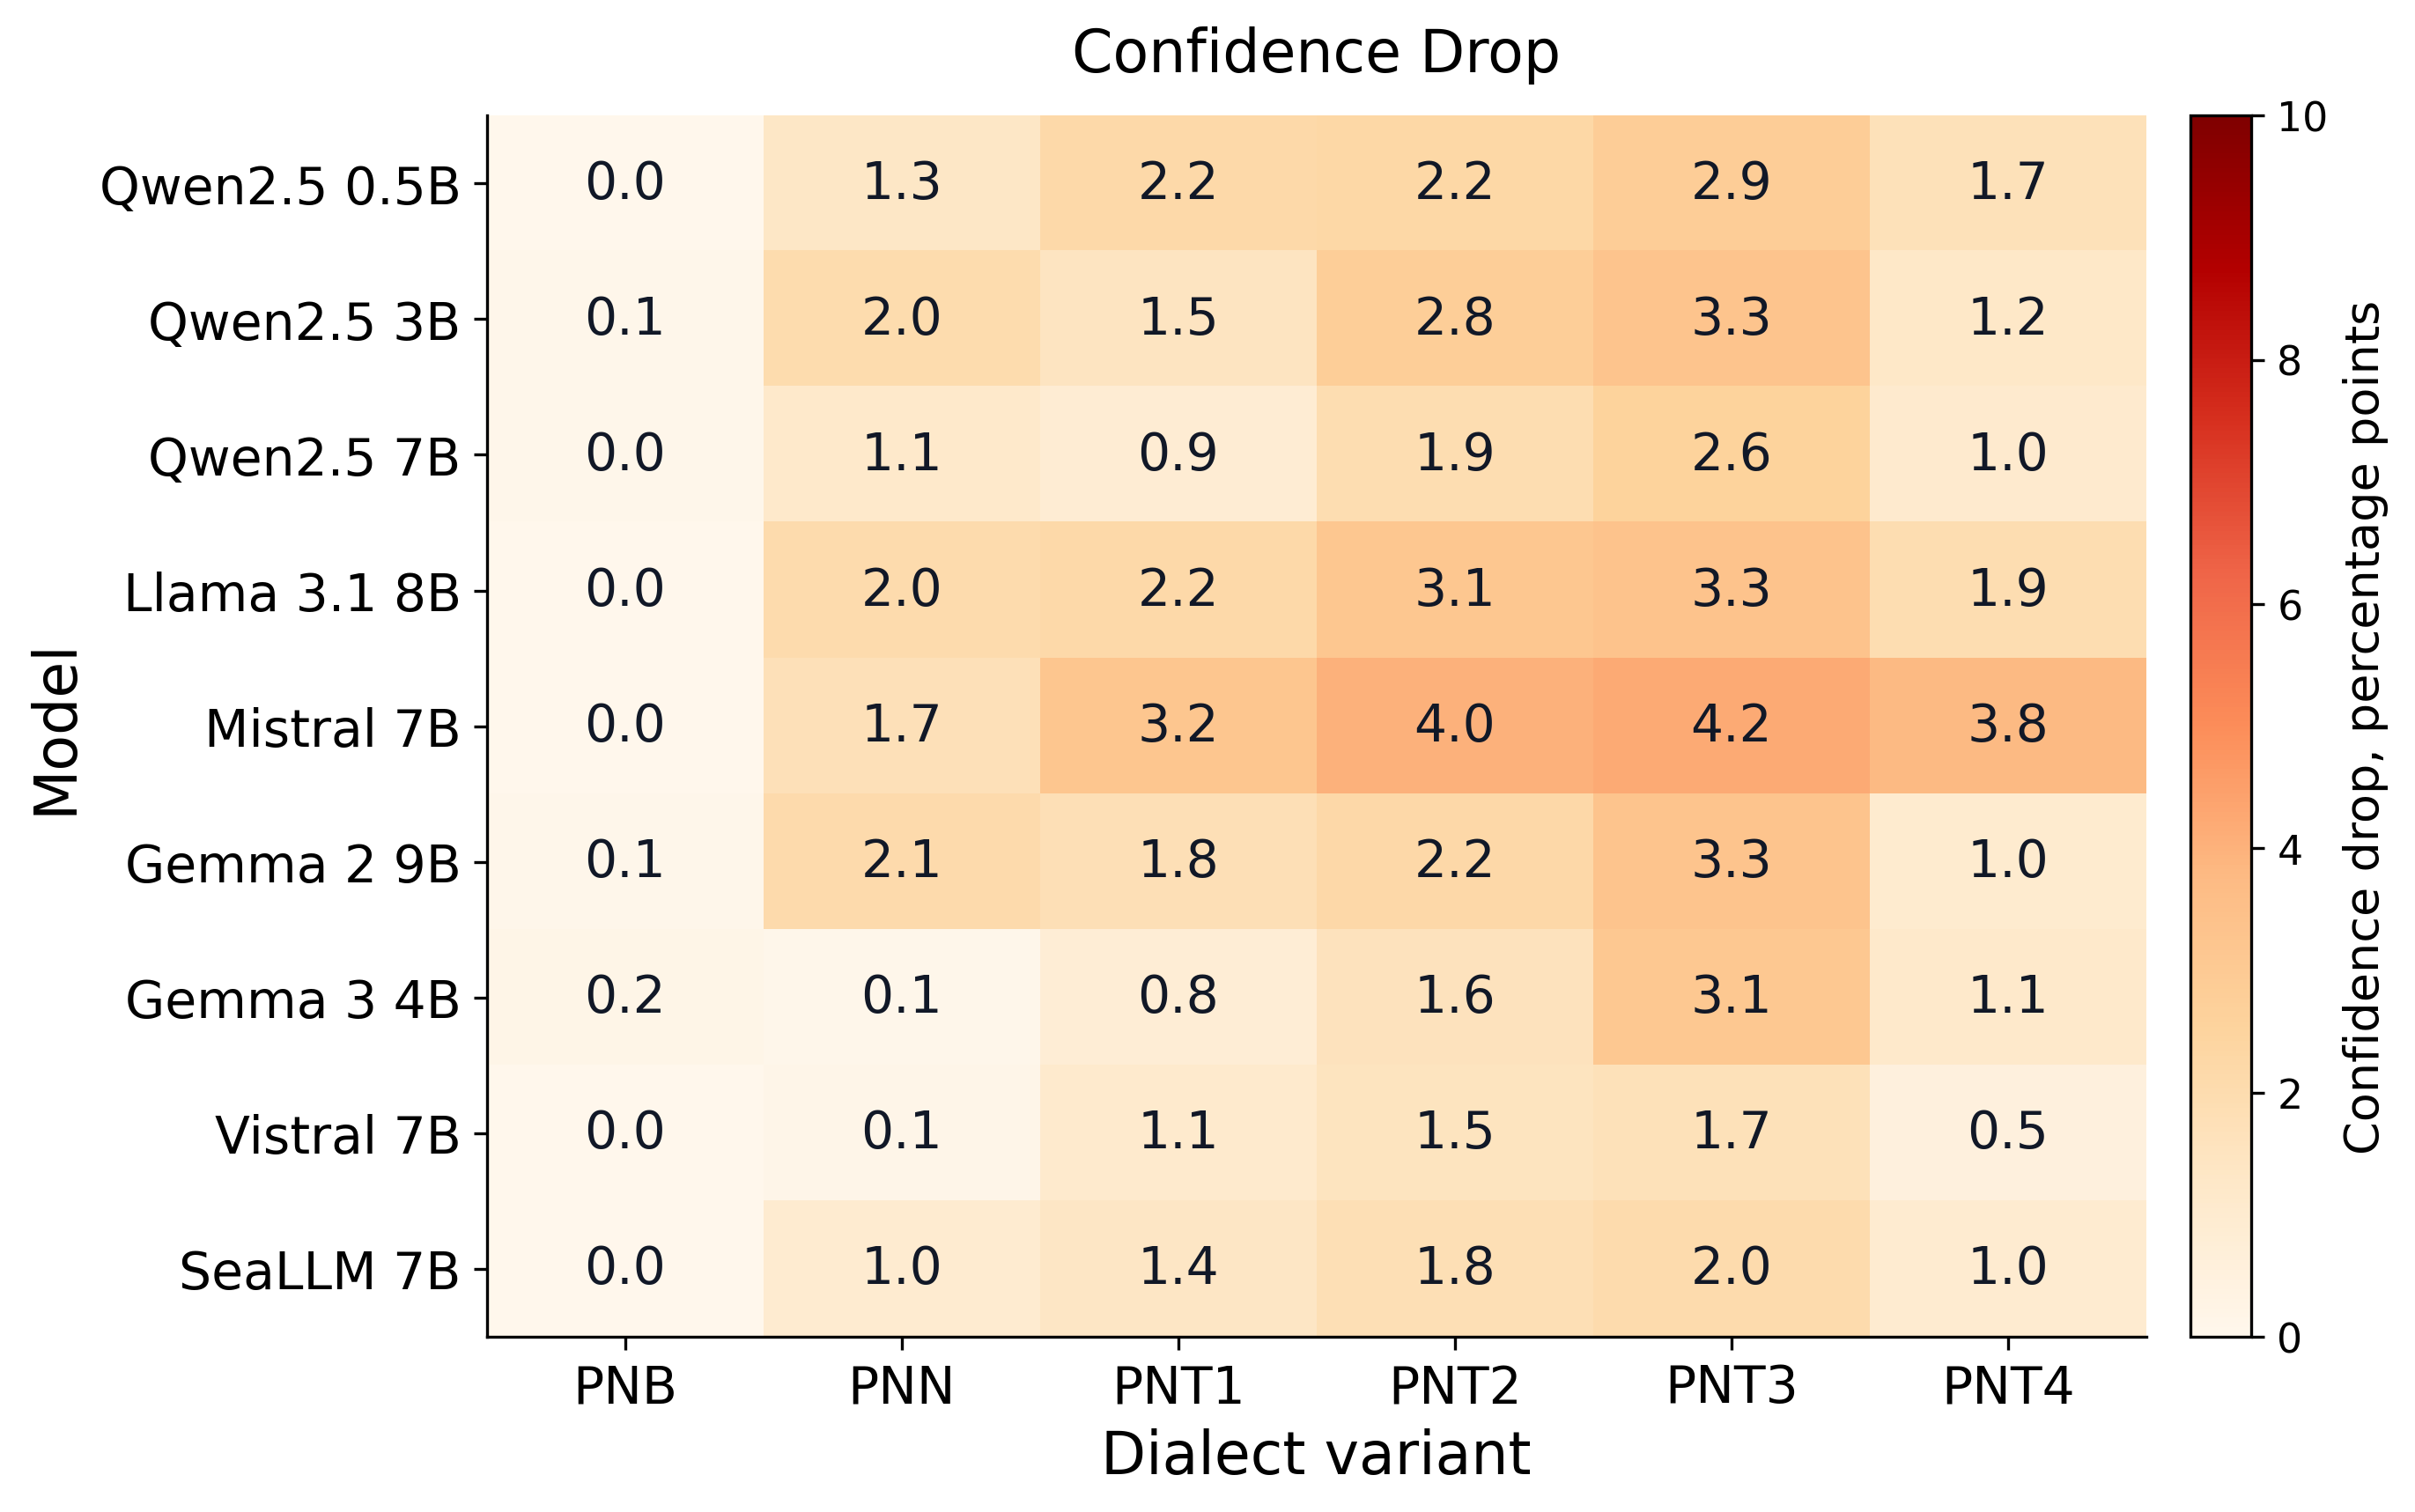

In [ ]:
if preserved_correct.empty:
    conf_heat = pd.DataFrame(0.0, index=CONF_DROP_MODEL_ORDER, columns=DIALECT_ORDER)
    conf_counts = pd.DataFrame(0, index=CONF_DROP_MODEL_ORDER, columns=DIALECT_ORDER)
else:
    conf_heat = (
        preserved_correct.groupby(['model_slug', 'variant'], observed=False)['confidence_drop']
        .mean()
        .unstack('variant')
        .reindex(index=CONF_DROP_MODEL_ORDER, columns=DIALECT_ORDER)
    )
    conf_counts = (
        preserved_correct.groupby(['model_slug', 'variant'], observed=False)['id']
        .size()
        .unstack('variant')
        .reindex(index=CONF_DROP_MODEL_ORDER, columns=DIALECT_ORDER)
        .fillna(0)
        .astype(int)
    )

plot_values = conf_heat.fillna(0.0).clip(lower=0) * 100
fig, ax = plt.subplots(figsize=(9.2, 5.8))
vmax = max(10.0, float(plot_values.to_numpy().max()) if plot_values.size else 10.0)
im = ax.imshow(plot_values, aspect='auto', cmap='OrRd', vmin=0, vmax=vmax)
ax.set_xticks(np.arange(len(DIALECT_ORDER)), DIALECT_ORDER)
ax.set_yticks(np.arange(len(CONF_DROP_MODEL_ORDER)), [MODEL_LABELS[m] for m in CONF_DROP_MODEL_ORDER])
ax.set_xlabel('Dialect variant', fontsize=16)
ax.set_ylabel('Model', fontsize=16)
ax.set_title('Confidence Drop', fontsize=16, pad=12)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

for i, model in enumerate(CONF_DROP_MODEL_ORDER):
    for j, dialect in enumerate(DIALECT_ORDER):
        n = int(conf_counts.loc[model, dialect]) if model in conf_counts.index and dialect in conf_counts.columns else 0
        if n == 0:
            text = '-'
            color = '#6b7280'
        else:
            text = f'{plot_values.loc[model, dialect]:.1f}'
            color = 'white' if plot_values.loc[model, dialect] > 0.55 * vmax else '#111827'
        ax.text(j, i, text, ha='center', va='center', fontsize=14, color=color)

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.025)
cbar.set_label('Confidence drop, percentage points', fontsize=13)
cbar.ax.tick_params(labelsize=11)
ax.grid(False)
fig.tight_layout()
save_direct_figure(fig, 'paper_figure_preserved_correct_confidence_drop')

In [ ]:
NORMALIZED_OUTPUT_DIRS = [
    ROOT / 'outputs' / 'normalized_direct_prompting',
    ROOT / 'outputs' / 'normalized_direct',
    ROOT / 'outputs' / 'direct_prompting_normalized',
]
NORMALIZER_EXPORT_JSONL = DIRECT_ARTIFACT_DIR / 'normalizer_hard_cases.jsonl'
NORMALIZER_EXPORT_CSV = DIRECT_ARTIFACT_DIR / 'normalizer_hard_cases.csv'

def compact_variant_text(variant_value):
    if not isinstance(variant_value, dict):
        return '' if variant_value is None else str(variant_value)
    pieces = []
    for key in ['context', 'premise', 'hypothesis', 'question', 'sentence', 'text']:
        value = variant_value.get(key)
        if value:
            pieces.append(f'{key}: {value}')
    options = variant_value.get('options')
    if isinstance(options, list) and options:
        pieces.append('options: ' + ' | '.join(map(str, options)))
    return ' || '.join(pieces)

def load_probe_case_lookup():
    lookup = {}
    if FINALIZED_PROBE.exists():
        with FINALIZED_PROBE.open(encoding='utf-8') as f:
            for line in f:
                if line.strip():
                    case = json.loads(line)
                    lookup[str(case.get('id'))] = case
    return lookup

def load_prompting_outputs(output_dir: Path) -> pd.DataFrame:
    rows = []
    if output_dir is None or not output_dir.exists():
        return pd.DataFrame()
    for path in sorted(output_dir.glob('*.jsonl')):
        model_slug = path.stem
        with path.open(encoding='utf-8') as f:
            for line in f:
                if not line.strip():
                    continue
                row = json.loads(line)
                if not str(row.get('raw_output') or '').strip() and not str(row.get('prediction') or '').strip():
                    continue
                task = DIRECT_TASK_MAP.get(str(row.get('task', '')).lower(), str(row.get('task', '')).upper())
                variant = row.get('dialect_group') or row.get('variant') or 'standard'
                variant = 'standard' if str(variant).lower() == 'standard' else str(variant)
                prediction = row.get('prediction')
                gold = row.get('gold')
                score = token_f1(prediction, gold) if task == 'QA' else exact_match(prediction, gold)
                correct = exact_match(prediction, gold) if task == 'QA' else score
                rows.append({
                    'model_slug': model_slug,
                    'task': task,
                    'id': str(row.get('id')),
                    'variant': variant,
                    'prediction': prediction,
                    'score': score,
                    'correct': correct,
                    'confidence': row.get('confidence', np.nan),
                })
    out = pd.DataFrame(rows)
    if not out.empty:
        out['model_slug'] = pd.Categorical(out['model_slug'], categories=MODEL_ORDER, ordered=True)
        out['task'] = pd.Categorical(out['task'], categories=TASK_ORDER, ordered=True)
        out['variant'] = pd.Categorical(out['variant'], categories=EXPECTED_VARIANTS, ordered=True)
    return out

hard_failure_rows = pd.DataFrame()
hard_case_summary = pd.DataFrame()
if not pair_df.empty:
    standard_correct_rows = pair_df[pair_df['standard_correct'] == 1.0].copy()
    standard_correct_rows['dialect_failed'] = (standard_correct_rows['correct'] == 0.0).astype(float)
    hard_case_summary = (
        standard_correct_rows.groupby(['model_slug', 'task', 'id'], observed=False)
        .agg(
            dialect_rows=('variant', 'nunique'),
            failed_dialects=('dialect_failed', 'sum'),
            failure_rate=('dialect_failed', 'mean'),
            mean_confidence_drop=('confidence_drop', 'mean'),
            failed_variant_list=('variant', lambda x: ', '.join([str(v) for v in x[standard_correct_rows.loc[x.index, 'dialect_failed'] == 1.0]])),
        )
        .reset_index()
    )
    hard_case_summary = hard_case_summary[
        (hard_case_summary['dialect_rows'] > 0)
        & (hard_case_summary['failed_dialects'] >= np.ceil(hard_case_summary['dialect_rows'] / 2))
    ].sort_values(['failed_dialects', 'failure_rate', 'mean_confidence_drop'], ascending=[False, False, False])
    hard_keys = hard_case_summary[['model_slug', 'task', 'id']]
    hard_failure_rows = standard_correct_rows.merge(hard_keys, on=['model_slug', 'task', 'id'], how='inner')
    hard_failure_rows = hard_failure_rows[hard_failure_rows['correct'] == 0.0].copy()

case_lookup = load_probe_case_lookup()
export_rows = []
for _, row in hard_case_summary.head(60).iterrows():
    case = case_lookup.get(str(row['id']), {})
    variants = case.get('variants', {}) if isinstance(case, dict) else {}
    export_rows.append({
        'model_slug': str(row['model_slug']),
        'model': MODEL_LABELS.get(str(row['model_slug']), str(row['model_slug'])),
        'task': str(row['task']),
        'id': str(row['id']),
        'failed_dialects': int(row['failed_dialects']),
        'dialect_rows': int(row['dialect_rows']),
        'failure_rate': float(row['failure_rate']),
        'failed_variant_list': row['failed_variant_list'],
        'standard_text': compact_variant_text(variants.get('standard')),
        **{f'{dialect}_text': compact_variant_text(variants.get(dialect)) for dialect in DIALECT_ORDER},
    })

hard_case_export = pd.DataFrame(export_rows)
hard_case_export.to_csv(NORMALIZER_EXPORT_CSV, index=False)
with NORMALIZER_EXPORT_JSONL.open('w', encoding='utf-8') as f:
    for row in export_rows:
        f.write(json.dumps(row, ensure_ascii=False) + '\n')
print(f'wrote {NORMALIZER_EXPORT_CSV}')
print(f'wrote {NORMALIZER_EXPORT_JSONL}')

normalized_output_dir = next((p for p in NORMALIZED_OUTPUT_DIRS if p.exists() and any(p.glob('*.jsonl'))), None)
normalized_df = load_prompting_outputs(normalized_output_dir) if normalized_output_dir else pd.DataFrame()

if hard_failure_rows.empty:
    normalizer_eval = pd.DataFrame(index=MODEL_ORDER, columns=['direct_failed_n', 'normalized_n', 'normalized_performance', 'rescue_rate'])
elif normalized_df.empty:
    normalizer_eval = pd.DataFrame(index=MODEL_ORDER)
    direct_failed_counts = hard_failure_rows.groupby('model_slug', observed=False).size().reindex(MODEL_ORDER)
    normalizer_eval['direct_failed_n'] = direct_failed_counts
    normalizer_eval['normalized_n'] = np.nan
    normalizer_eval['normalized_performance'] = np.nan
    normalizer_eval['rescue_rate'] = np.nan
else:
    norm_subset = normalized_df.merge(
        hard_failure_rows[['model_slug', 'task', 'id', 'variant']],
        on=['model_slug', 'task', 'id', 'variant'],
        how='inner',
    )
    normalizer_eval = (
        norm_subset.groupby('model_slug', observed=False)
        .agg(
            normalized_n=('id', 'size'),
            normalized_performance=('score', 'mean'),
            rescue_rate=('correct', 'mean'),
        )
        .reindex(MODEL_ORDER)
    )
    normalizer_eval['direct_failed_n'] = hard_failure_rows.groupby('model_slug', observed=False).size().reindex(MODEL_ORDER)
    normalizer_eval = normalizer_eval[['direct_failed_n', 'normalized_n', 'normalized_performance', 'rescue_rate']]

normalizer_eval.index.name = 'model_slug'
formatted_normalizer = normalizer_eval.reset_index()
formatted_normalizer['Model'] = formatted_normalizer['model_slug'].map(MODEL_LABELS)
formatted_normalizer = formatted_normalizer[['Model', 'direct_failed_n', 'normalized_n', 'normalized_performance', 'rescue_rate']]
formatted_normalizer = formatted_normalizer.rename(columns={
    'direct_failed_n': 'Hard failed rows',
    'normalized_n': 'Normalized rows',
    'normalized_performance': 'Normalized performance',
    'rescue_rate': 'Rescue rate',
})
for col in ['Hard failed rows', 'Normalized rows']:
    formatted_normalizer[col] = formatted_normalizer[col].map(lambda x: '-' if pd.isna(x) or int(x) == 0 else str(int(x)))
for col in ['Normalized performance', 'Rescue rate']:
    formatted_normalizer[col] = formatted_normalizer[col].map(pct_or_dash)

save_direct_table(formatted_normalizer, 'paper_table_normalizer_rescue_probe')
if normalized_output_dir:
    print(f'normalized outputs loaded from {normalized_output_dir}')
else:
    print('No normalized-direct outputs found yet; table keeps normalized metrics as dash.')
display(formatted_normalizer)


wrote ..\paper_artifacts\direct_prompting\normalizer_hard_cases.csv
wrote ..\paper_artifacts\direct_prompting\normalizer_hard_cases.jsonl
wrote ..\paper_artifacts\direct_prompting\paper_table_normalizer_rescue_probe.csv
wrote ..\paper_artifacts\direct_prompting\paper_table_normalizer_rescue_probe.tex
No normalized-direct outputs found yet; table keeps normalized metrics as dash.


,Model,Hard failed rows,Normalized rows,Normalized performance,Rescue rate
0,Qwen2.5 0.5B,83,-,-,-
1,Qwen2.5 3B,85,-,-,-
2,Qwen2.5 7B,84,-,-,-
3,Llama 3.1 8B,72,-,-,-
4,Mistral 7B,116,-,-,-
5,Gemma 2 9B,80,-,-,-
6,Gemma 3 4B,67,-,-,-
7,Vistral 7B,36,-,-,-
8,SeaLLM 7B,83,-,-,-
9,GPT-4o,47,-,-,-


wrote ..\paper_artifacts\direct_prompting\paper_figure_normalizer_rescue_probe.png
wrote ..\paper_artifacts\direct_prompting\paper_figure_normalizer_rescue_probe.pdf


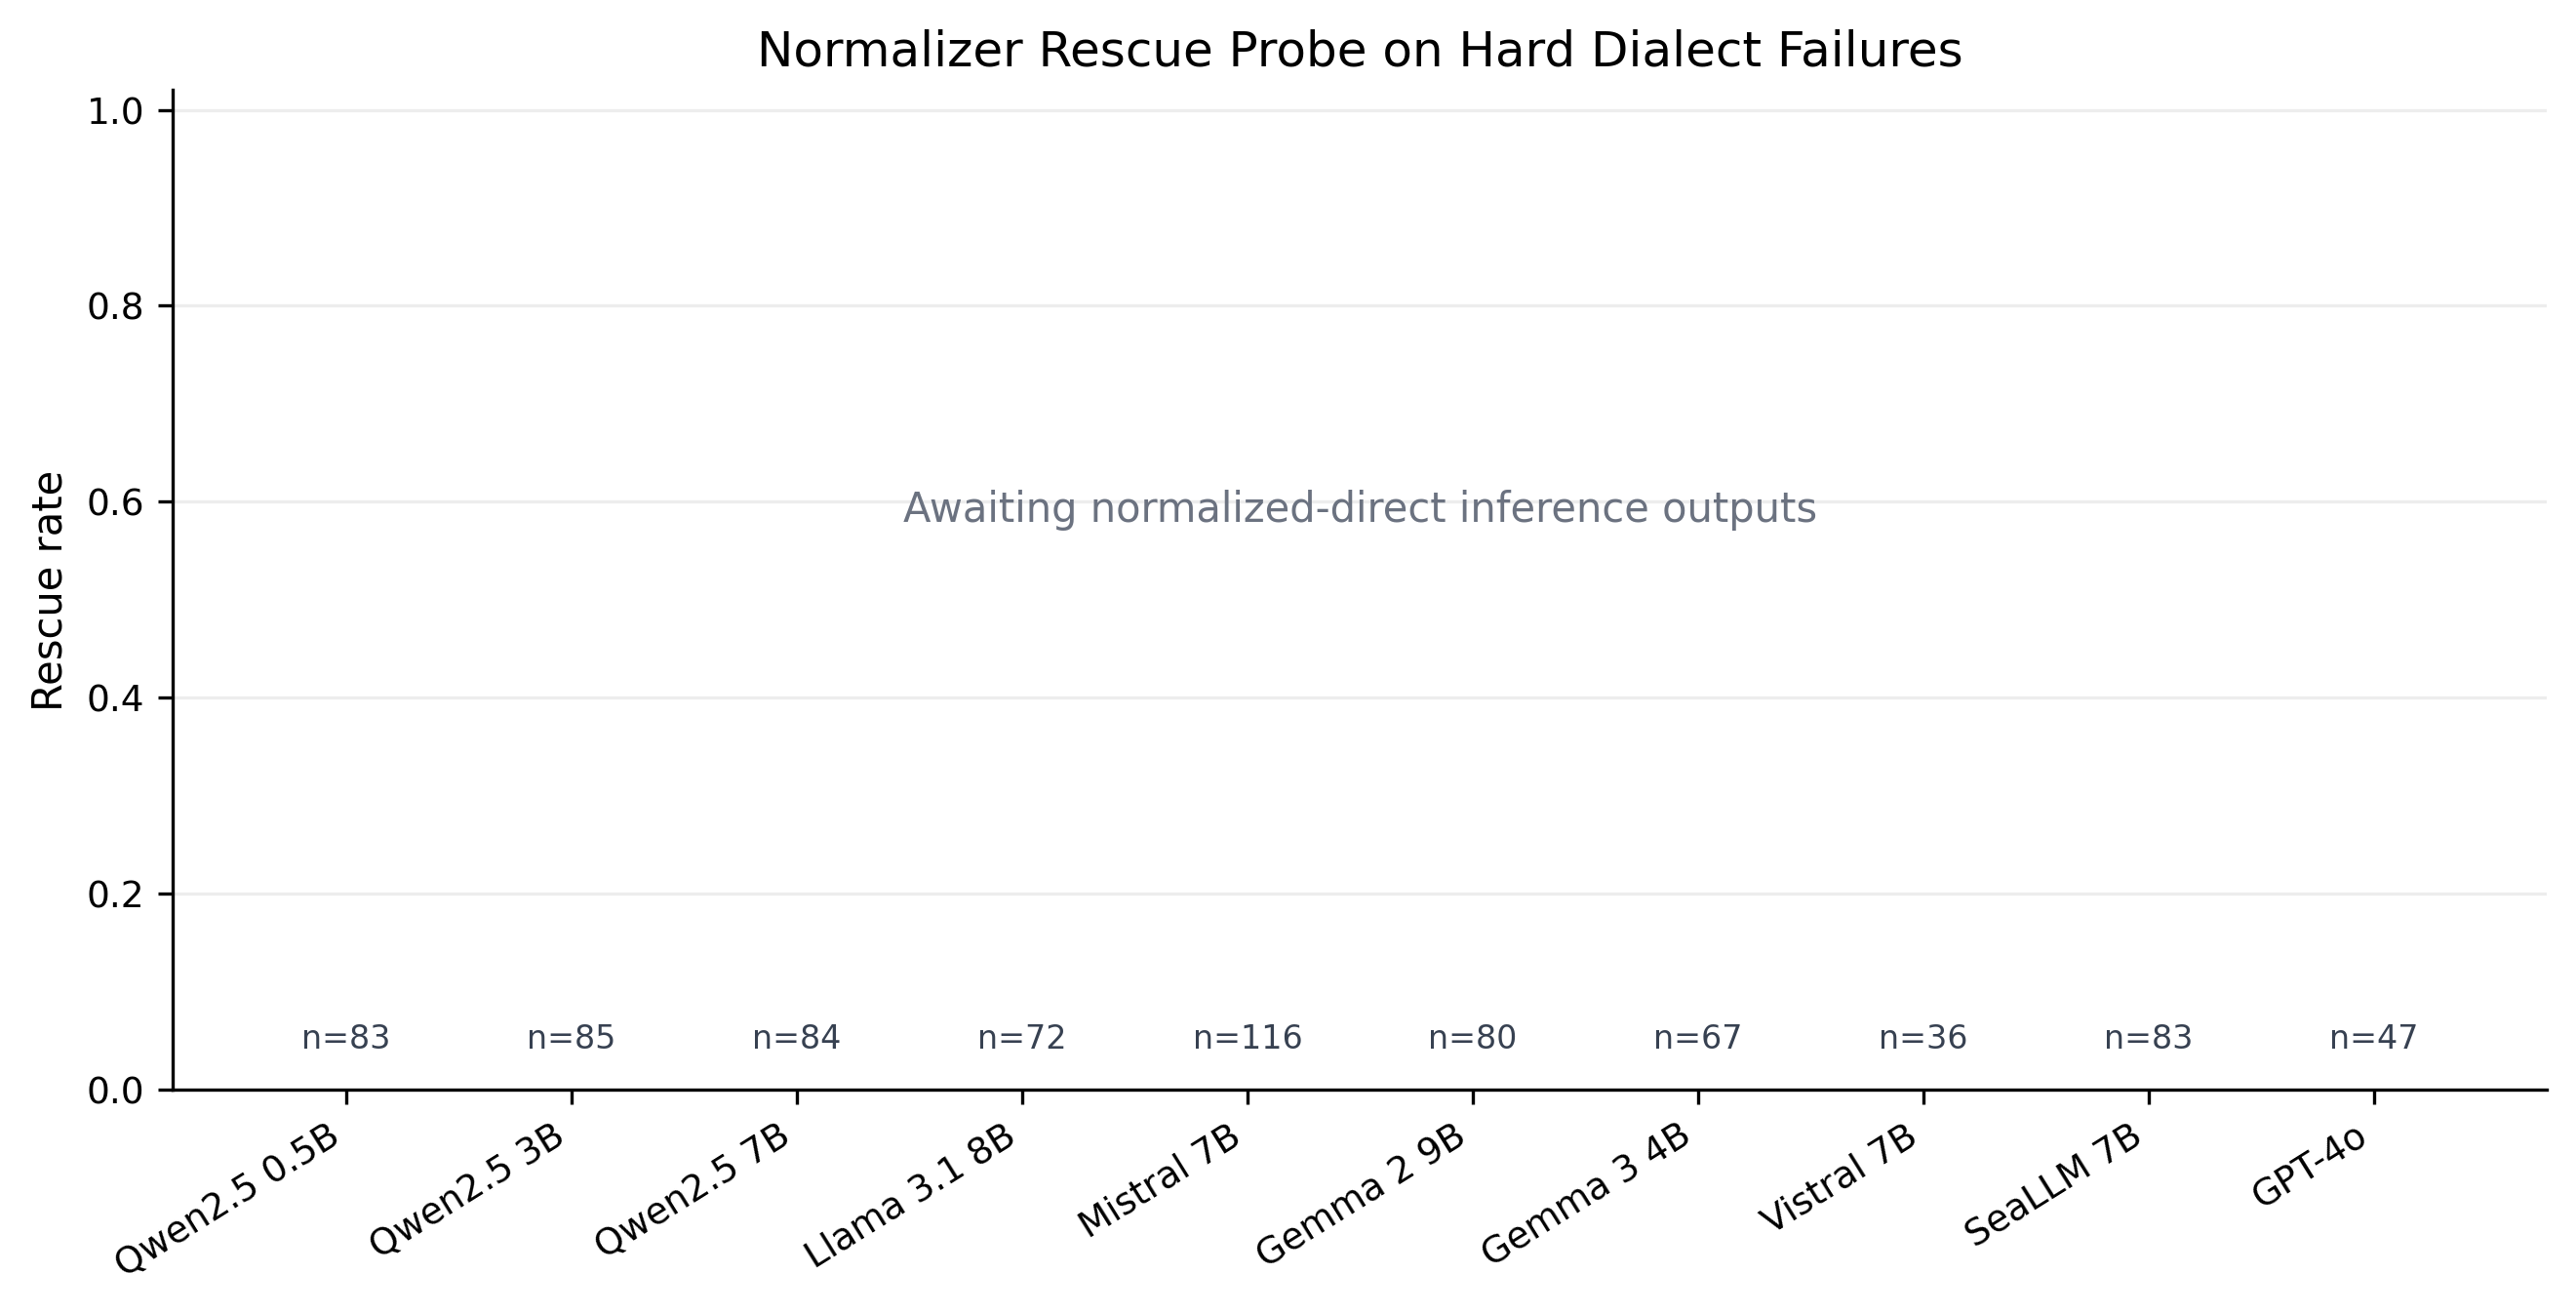

In [ ]:
plot_normalizer = normalizer_eval.copy() if 'normalizer_eval' in globals() else pd.DataFrame()
if plot_normalizer.empty:
    plot_normalizer = pd.DataFrame(index=MODEL_ORDER, data={'rescue_rate': 0.0, 'direct_failed_n': 0})
else:
    plot_normalizer = plot_normalizer.reindex(MODEL_ORDER)

x = np.arange(len(MODEL_ORDER))
rescue_values = plot_normalizer['rescue_rate'].fillna(0.0)
failed_counts = plot_normalizer['direct_failed_n'].fillna(0.0)

fig, ax = plt.subplots(figsize=(8.9, 4.6))
bars = ax.bar(x, rescue_values, color='#4C78A8', width=0.58, label='Rescue rate after normalization')
ax.set_ylim(0, 1.02)
ax.set_ylabel('Rescue rate')
ax.set_xticks(x, [MODEL_LABELS[m] for m in MODEL_ORDER], rotation=32, ha='right')
ax.set_title('Normalizer Rescue Probe on Hard Dialect Failures')
ax.grid(axis='y', alpha=0.22)

for i, bar in enumerate(bars):
    n = int(failed_counts.iloc[i]) if pd.notna(failed_counts.iloc[i]) else 0
    label = '-' if n == 0 else f'n={n}'
    ax.text(bar.get_x() + bar.get_width() / 2, max(bar.get_height() + 0.025, 0.035), label, ha='center', va='bottom', fontsize=8, color='#374151')

if normalized_df.empty:
    ax.text(
        0.5, 0.58,
        'Awaiting normalized-direct inference outputs',
        transform=ax.transAxes,
        ha='center',
        va='center',
        fontsize=10,
        color='#6b7280',
    )

fig.tight_layout()
save_direct_figure(fig, 'paper_figure_normalizer_rescue_probe')
